## 1. What this notebook computes

Theorem **T3** of the Revision record says: in the Kohn-Sham model of the fermion
field dirac16complex in the author's deflating primordial field, every
self-consistent state of the universe with the bare mass $+m$, the coupling
$\lambda$ and the tip angle $\theta$ has an exact partner in the universe with the
bare mass $-m$, the **same** coupling $+\lambda$ and the tip angle $\pi - \theta$,
with the same levels, occupations, energies and energy-momentum profiles and the
opposite scalar density. T3 is PROVED by exact algebra (Wolfram 10 of 10 checks,
sympy 13 of 13). This notebook does not prove it again; it **watches it happen**
in the Rust Kohn-Sham solver of the repository, which knows nothing about T3 and
simply solves each universe on its own.

The notebook

- checks the eight real $16 \times 16$ gamma matrices of the record, builds from
  them the chirality matrix $\Gamma$ and checks that $\Gamma$ is the map of T3;
- builds the Rust program `revision_ks_solver` with cargo;
- solves four kinds of universes: A (mass $+m$, tip angle $0$; the canonical
  state of the record), B (mass $-m$, coupling $+\lambda$, tip angle $\pi$; the T3
  partner of A), C (mass $-m$, coupling $+\lambda$, tip angle $0$; the **negative
  control** with the untransformed tip) and D (mass $-m$, coupling $-\lambda$, tip
  angle $\pi$; the **wrong partner** with the reversed coupling);
- reproduces, number by number, the solver's own T3 self-test stored in the
  record `Revision/kohn_sham/reports/ks-rust-solver.json`;
- compares A and B level by level and point by point, for 8, 136 and 688
  particles, at the five instants of the deflating history, for five couplings and
  at three temperatures (62 runs of the solver), and shows that C and D differ;
- checks that every A run reproduces the committed canonical state of the record,
  and that the free zero modes and a level of the control agree with formulas
  derived here by hand;
- draws ten figures that put the universes on top of each other.

It takes about one to two minutes (longer on a laptop).

## 2. How to run this notebook

**Step 1. What this notebook does and what it needs.**

Notebook 19a (The Rust Kohn-Sham solver for the universes of mass +M and -M) is the file
`Revision/textbook/notebooks/19a_t3_rust_pairs.ipynb` of the repository Dirac_claude. It
checks the eight real 16 x 16 gamma matrices of the record, builds from them the
chirality matrix Gamma and checks that Gamma is the block map of theorem T3. Then it
builds the Rust Kohn-Sham solver of the repository with cargo (about a minute when the
program is missing, a second when it is up to date) and solves the Kohn-Sham problem of
dirac16complex in the deflating primordial field for the universe of mass +M (bare mass
m, coupling lambda, tip angle 0), for its partner of theorem T3 (bare mass -m, the same
coupling, tip angle pi), for the negative control with the untransformed tip (bare mass
-m, tip angle 0) and for the wrong partner with the reversed coupling (-m, -lambda, tip
angle pi). It does this for 8, 136 and 688 particles, at the five instants of the
deflating history, for five couplings and at three temperatures (62 runs). It checks that
the partners have the same levels, occupations, energies and energy-momentum profiles and
the opposite scalar density, that the controls differ, that the +M runs reproduce the
committed canonical states, that the solver's own T3 self-test is reproduced number by
number, that the runs equal the record's own numerical demonstration of T3 in the 19
states that both solve, and that the free zero modes and the sub-gap level of the control
agree with their closed forms, and it draws ten overlay figures. The solver writes its
raw output (about 2 MB) into the folder `Revision/kohn_sham/solver/target/textbook_19a`,
which git ignores. It needs a computer with Windows 11, macOS or Linux, an internet
connection for the installation, the program Git, and Python 3.12 or newer (the notebooks
were built with Python 3.14.5) with these packages at exactly these versions: numpy
2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab 4.4.10, nbformat 5.10.4,
nbclient 0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The notebook itself imports numpy
and matplotlib; the other packages run Jupyter, the program that shows and runs
notebooks. It also needs Rust (the program cargo, version 1.91.1 or newer), because it
runs the Rust program revision_ks_solver, which is part of the repository and is built on
your computer.

**Step 2. Install Git and Python (once per computer).**

A terminal is the window in which you type commands: on Windows the app Windows
PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux any
terminal (it runs the shell bash). Type every command of this section into a terminal
exactly as printed, one line at a time, and press Enter after each line.

Windows: download Git from https://git-scm.com/download/win and install it with the
default choices. Download Python from https://www.python.org/downloads/ and run the
installer; in its first window tick the box "Add python.exe to PATH" before you click
"Install Now".

macOS: download Python from https://www.python.org/downloads/ and run the installer. Then
open the app Terminal and run this command, which installs Git and the compiler tools:

macOS (zsh):

    xcode-select --install

Linux (Debian or Ubuntu; other distributions have packages of the same names): run these
two commands:

Linux (bash):

    sudo apt update
    sudo apt install git python3 python3-venv

Then close the terminal and open a NEW one (a terminal opened before the installation
does not know the new programs), and check the version of Python; it must print 3.12 or a
higher number:

Windows (PowerShell):

    py -3 --version

macOS (zsh) and Linux (bash):

    python3 --version

If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
3.12 with the following three commands, and in Step 3 type `python3.12` instead of
`python3` in the command that creates the environment:

Linux (bash), only when the version is too low:

    sudo add-apt-repository ppa:deadsnakes/ppa
    sudo apt update
    sudo apt install python3.12 python3.12-venv

**Step 3. Get the repository and install the packages (once per computer).**

The commands below download the repository (a few hundred megabytes; the folder then
needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
folder, create a private Python environment in the folder dirac-book-env inside your home
folder (a private environment is a folder with its own copy of Python and of the
packages, so that nothing else on your computer is changed), activate it (from then on
the commands `python` and `jupyter` typed in this terminal are those of the environment,
and the prompt starts with (dirac-book-env)), and install the packages at the pinned
versions (this downloads about 90 MB and takes a few minutes; the environment takes about
400 MB of disk space). If you have done this step before, for this or for another
notebook, skip it and go to Step 4; to get the newest version of the repository, run `git
pull` in the repository folder after Step 4.

Windows (PowerShell):

    cd $HOME
    git clone https://github.com/once-ere/Dirac_claude.git
    py -3 -m venv "$HOME\dirac-book-env"
    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

The line with `Set-ExecutionPolicy` allows PowerShell to run the activation script in
this one window only; it changes nothing permanently.

macOS (zsh):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

Linux (bash):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

**Step 4. In every new terminal: activate the environment and go into the repository
folder.**

Every later step starts in the repository folder with the environment active. Run these
lines whenever you open a new terminal (they do no harm if the environment is already
active):

Windows (PowerShell):

    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    cd "$HOME\Dirac_claude"

macOS (zsh) and Linux (bash):

    source ~/dirac-book-env/bin/activate
    cd ~/Dirac_claude

**Step 5. Install Rust and build the Rust program (Rust once per computer, the build once
per program).**

Windows: download `rustup-init.exe` from https://rustup.rs, run it and accept the default
choices; if it reports that the Visual Studio C++ Build Tools are missing, let it install
them (or install the workload "Desktop development with C++" from
https://visualstudio.microsoft.com/visual-cpp-build-tools/ and run `rustup-init.exe`
again). macOS and Linux: run the command below and accept the default choice (on Linux
first run `sudo apt install build-essential`, which provides the linker that Rust needs).

macOS (zsh) and Linux (bash):

    curl --proto "=https" --tlsv1.2 -sSf https://sh.rustup.rs | sh

Then close the terminal, open a new one, do Step 4 again, and check the version of cargo;
it must print 1.91.1 or a newer version:

Windows, macOS and Linux:

    cargo --version

Build the program with the following command, in the repository folder (the same command
on all three systems):

Windows, macOS and Linux:

    cargo build --release --manifest-path Revision/kohn_sham/solver/Cargo.toml

The first build takes about 1 minute; later builds reuse the result and take a few
seconds. The program is then the file
`Revision/kohn_sham/solver/target/release/revision_ks_solver` (on Windows with the ending
`.exe`). The notebook runs the same build command itself before it uses the program (it
takes a second when the program is up to date), so the notebook also works if you skip
this build; building here first shows any problem with Rust before the notebook starts.

**Step 6. Run the notebook in JupyterLab.**

In the repository folder, with the environment active, run these two lines (the first one
goes into the folder of the notebooks):

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter lab 19a_t3_rust_pairs.ipynb

JupyterLab opens in your web browser and shows the notebook (if no browser window opens,
copy the address that starts with `http://localhost:8888/lab` from the terminal into the
address bar of your browser). The name at the top right of the notebook must read Python
3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the label to its
left shows `[*]`; when it has finished, the label shows a number. The notebook has
finished when the last code cell shows a number; this takes about 2 minutes on a typical
laptop. Scroll to the end and compare the last printed lines with the lines in the step
"What the notebook writes and what you must see" below. To keep the results, save the
notebook (menu File > Save Notebook). To stop JupyterLab, choose the menu File > Shut
Down, or press Ctrl+C twice in the terminal.

**Step 7. Or run the notebook without a browser (headless).**

In the repository folder, with the environment active, run:

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter nbconvert --to notebook --execute --inplace 19a_t3_rust_pairs.ipynb

This runs every cell from the top to the bottom and saves the results into the notebook
file. A failed check stops it with an error message that contains AssertionError and the
name of the check. If the command ends with a line that starts with `[NbConvertApp]
Writing` and shows no error, every check passed; open the notebook with `jupyter lab
19a_t3_rust_pairs.ipynb` (in the same folder, without running the cells again) to read
the printed lines and see the figures.

**Step 8. What the notebook writes and what you must see.**

The notebook writes (or overwrites) these files:

- `Revision/textbook/figures/19a.captions.json`
- `Revision/textbook/figures/19a_1_level_ladder.png`
- `Revision/textbook/figures/19a_2_level_differences.png`
- `Revision/textbook/figures/19a_3_density_profiles.png`
- `Revision/textbook/figures/19a_4_mass_and_potential.png`
- `Revision/textbook/figures/19a_5_emt_profiles.png`
- `Revision/textbook/figures/19a_6_zero_modes_n8.png`
- `Revision/textbook/figures/19a_7_history_energy.png`
- `Revision/textbook/figures/19a_8_history_agreement.png`
- `Revision/textbook/figures/19a_9_coupling_scan.png`
- `Revision/textbook/figures/19a_10_thermal_states.png`

It changes no other file of the repository except the Rust build folder `target` next to
each `Cargo.toml` it builds; running it headless or saving it in JupyterLab also rewrites
the notebook file itself. It does not use the internet while it runs. The files it writes
are the same files that are stored in the repository (on another computer a figure may
differ in a few bytes, which is harmless). To get the stored versions back, run this
command in the repository folder (it also undoes every change you made yourself in the
folder Revision/textbook):

Windows, macOS and Linux:

    git checkout -- Revision/textbook

Every check of the notebook prints a line that starts with PASS. At the end of the
notebook (the output of its last code cell) you must see exactly these lines:

    PASS every figure file of this notebook exists
    ALL 37 CHECKS PASSED (notebook 19a)

and the notebook must show 10 figures below the cells that draw them.

**Step 9. If something goes wrong.**

- "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
  without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
  again. If the error remains, another Python installation has registered its own kernel
  called python3; with the environment active, run the following command and start
  JupyterLab again:

      python -m ipykernel install --user --name python3

- "FileNotFoundError: The repository folder was not found": the notebook was opened from
  a copy outside the repository. Open the file
  `Revision/textbook/notebooks/19a_t3_rust_pairs.ipynb` inside the folder Dirac_claude.
- "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
  downloaded before; skip the line with `git clone`.
- Windows: "running scripts is disabled on this system": run the line with
  `Set-ExecutionPolicy` and then the activation line again. "py is not recognized": use
  `python` instead of `py -3`; "python is not recognized": install Python again and tick
  "Add python.exe to PATH".
- Linux: "ensurepip is not available" when the environment is created: run `sudo apt
  install python3-venv` and repeat Step 3.
- "jupyter is not recognized" or "command not found: jupyter": the environment is not
  active; do Step 4 (or type `python -m jupyter` instead of `jupyter`).
- Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
  loop" and zmq: this is a message of the package pyzmq, not an error; the run continues
  normally.
- A red box with "Matplotlib is building the font cache; this may take a moment." in the
  first run after the installation: this is a message, not an error; the run continues
  and the message does not come again.
- An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
  and Run All Cells; if it fails again, install the packages again with the pip commands
  of Step 3, because a different package version can change the last digits of a result.
- "cargo is not recognized" or "command not found: cargo" or "cargo was not found": open
  a new terminal after installing Rust, do Step 4 again, and start JupyterLab from this
  terminal.
- "linker link.exe not found" (Windows) or "linker cc not found" (Linux): install the C++
  Build Tools (Windows) or build-essential (Linux) as described in Step 5 and build
  again.
- A cell shows the label with the star for a minute or more: this is normal for the cells
  that run the history and the coupling scan: they start the Rust program 17 to 27 times,
  each run takes about a second on a fast computer and up to five seconds on a laptop.
  Wait until the label shows a number.
- RuntimeError: the solver failed for a state: the error message ends with the last lines
  the solver printed. The solver and its input files must be the committed versions; get
  them back and run the notebook again.

      git checkout -- Revision/kohn_sham Revision/algebra/gammas.json

- An AssertionError names a comparison with the record: the line above the error prints
  the largest difference. Differences in the last two or three digits are rounding
  effects of another computer and stay far below the tolerance; a larger difference means
  that the solver or its input files were changed.
- You want the disk space of the solver output back: the folder
  `Revision/kohn_sham/solver/target/textbook_19a` holds only the raw output of the last
  run (ignored by git); delete it at any time, the notebook writes it again.

The first code cell below (the set-up cell) repeats these instructions as comments; then
it imports the packages, finds the repository folder and defines the helpers
`save_figure` (saves a figure and shows it), `check` (stops with an AssertionError when a
check fails, prints a PASS line when it passes), `report` (prints a key number as a
RESULT line) and `all_checks_passed` (prints the last line).

In [1]:
# HOW TO RUN NOTEBOOK 19a (the complete instructions)
#
# STEP 1. WHAT THIS NOTEBOOK DOES AND WHAT IT NEEDS.
#
# Notebook 19a (The Rust Kohn-Sham solver for the universes of mass +M and -M) is the
# file Revision/textbook/notebooks/19a_t3_rust_pairs.ipynb of the repository
# Dirac_claude. It checks the eight real 16 x 16 gamma matrices of the record, builds
# from them the chirality matrix Gamma and checks that Gamma is the block map of theorem
# T3. Then it builds the Rust Kohn-Sham solver of the repository with cargo (about a
# minute when the program is missing, a second when it is up to date) and solves the
# Kohn-Sham problem of dirac16complex in the deflating primordial field for the universe
# of mass +M (bare mass m, coupling lambda, tip angle 0), for its partner of theorem T3
# (bare mass -m, the same coupling, tip angle pi), for the negative control with the
# untransformed tip (bare mass -m, tip angle 0) and for the wrong partner with the
# reversed coupling (-m, -lambda, tip angle pi). It does this for 8, 136 and 688
# particles, at the five instants of the deflating history, for five couplings and at
# three temperatures (62 runs). It checks that the partners have the same levels,
# occupations, energies and energy-momentum profiles and the opposite scalar density,
# that the controls differ, that the +M runs reproduce the committed canonical states,
# that the solver's own T3 self-test is reproduced number by number, that the runs equal
# the record's own numerical demonstration of T3 in the 19 states that both solve, and
# that the free zero modes and the sub-gap level of the control agree with their closed
# forms, and it draws ten overlay figures. The solver writes its raw output (about 2 MB)
# into the folder Revision/kohn_sham/solver/target/textbook_19a, which git ignores. It
# needs a computer with Windows 11, macOS or Linux, an internet connection for the
# installation, the program Git, and Python 3.12 or newer (the notebooks were built with
# Python 3.14.5) with these packages at exactly these versions: numpy 2.4.6, sympy
# 1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab 4.4.10, nbformat 5.10.4, nbclient
# 0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The notebook itself imports numpy and
# matplotlib; the other packages run Jupyter, the program that shows and runs notebooks.
# It also needs Rust (the program cargo, version 1.91.1 or newer), because it runs the
# Rust program revision_ks_solver, which is part of the repository and is built on your
# computer.
#
# STEP 2. INSTALL GIT AND PYTHON (ONCE PER COMPUTER).
#
# A terminal is the window in which you type commands: on Windows the app Windows
# PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux
# any terminal (it runs the shell bash). Type every command of this section into a
# terminal exactly as printed, one line at a time, and press Enter after each line.
#
# Windows: download Git from https://git-scm.com/download/win and install it with the
# default choices. Download Python from https://www.python.org/downloads/ and run the
# installer; in its first window tick the box "Add python.exe to PATH" before you click
# "Install Now".
#
# macOS: download Python from https://www.python.org/downloads/ and run the installer.
# Then open the app Terminal and run this command, which installs Git and the compiler
# tools:
#
# macOS (zsh):
#     xcode-select --install
#
# Linux (Debian or Ubuntu; other distributions have packages of the same names): run
# these two commands:
#
# Linux (bash):
#     sudo apt update
#     sudo apt install git python3 python3-venv
#
# Then close the terminal and open a NEW one (a terminal opened before the installation
# does not know the new programs), and check the version of Python; it must print 3.12 or
# a higher number:
#
# Windows (PowerShell):
#     py -3 --version
#
# macOS (zsh) and Linux (bash):
#     python3 --version
#
# If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
# 3.12 with the following three commands, and in Step 3 type python3.12 instead of
# python3 in the command that creates the environment:
#
# Linux (bash), only when the version is too low:
#     sudo add-apt-repository ppa:deadsnakes/ppa
#     sudo apt update
#     sudo apt install python3.12 python3.12-venv
#
# STEP 3. GET THE REPOSITORY AND INSTALL THE PACKAGES (ONCE PER COMPUTER).
#
# The commands below download the repository (a few hundred megabytes; the folder then
# needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
# folder, create a private Python environment in the folder dirac-book-env inside your
# home folder (a private environment is a folder with its own copy of Python and of the
# packages, so that nothing else on your computer is changed), activate it (from then on
# the commands python and jupyter typed in this terminal are those of the environment,
# and the prompt starts with (dirac-book-env)), and install the packages at the pinned
# versions (this downloads about 90 MB and takes a few minutes; the environment takes
# about 400 MB of disk space). If you have done this step before, for this or for another
# notebook, skip it and go to Step 4; to get the newest version of the repository, run
# git pull in the repository folder after Step 4.
#
# Windows (PowerShell):
#     cd $HOME
#     git clone https://github.com/once-ere/Dirac_claude.git
#     py -3 -m venv "$HOME\dirac-book-env"
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# The line with Set-ExecutionPolicy allows PowerShell to run the activation script in
# this one window only; it changes nothing permanently.
#
# macOS (zsh):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# Linux (bash):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# STEP 4. IN EVERY NEW TERMINAL: ACTIVATE THE ENVIRONMENT AND GO INTO THE REPOSITORY
# FOLDER.
#
# Every later step starts in the repository folder with the environment active. Run these
# lines whenever you open a new terminal (they do no harm if the environment is already
# active):
#
# Windows (PowerShell):
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     cd "$HOME\Dirac_claude"
#
# macOS (zsh) and Linux (bash):
#     source ~/dirac-book-env/bin/activate
#     cd ~/Dirac_claude
#
# STEP 5. INSTALL RUST AND BUILD THE RUST PROGRAM (RUST ONCE PER COMPUTER, THE BUILD ONCE
# PER PROGRAM).
#
# Windows: download rustup-init.exe from https://rustup.rs, run it and accept the default
# choices; if it reports that the Visual Studio C++ Build Tools are missing, let it
# install them (or install the workload "Desktop development with C++" from
# https://visualstudio.microsoft.com/visual-cpp-build-tools/ and run rustup-init.exe
# again). macOS and Linux: run the command below and accept the default choice (on Linux
# first run sudo apt install build-essential, which provides the linker that Rust needs).
#
# macOS (zsh) and Linux (bash):
#     curl --proto "=https" --tlsv1.2 -sSf https://sh.rustup.rs | sh
#
# Then close the terminal, open a new one, do Step 4 again, and check the version of
# cargo; it must print 1.91.1 or a newer version:
#
# Windows, macOS and Linux:
#     cargo --version
#
# Build the program with the following command, in the repository folder (the same
# command on all three systems):
#
# Windows, macOS and Linux:
#     cargo build --release --manifest-path Revision/kohn_sham/solver/Cargo.toml
#
# The first build takes about 1 minute; later builds reuse the result and take a few
# seconds. The program is then the file
# Revision/kohn_sham/solver/target/release/revision_ks_solver (on Windows with the ending
# .exe). The notebook runs the same build command itself before it uses the program (it
# takes a second when the program is up to date), so the notebook also works if you skip
# this build; building here first shows any problem with Rust before the notebook starts.
#
# STEP 6. RUN THE NOTEBOOK IN JUPYTERLAB.
#
# In the repository folder, with the environment active, run these two lines (the first
# one goes into the folder of the notebooks):
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter lab 19a_t3_rust_pairs.ipynb
#
# JupyterLab opens in your web browser and shows the notebook (if no browser window
# opens, copy the address that starts with http://localhost:8888/lab from the terminal
# into the address bar of your browser). The name at the top right of the notebook must
# read Python 3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the
# label to its left shows [*]; when it has finished, the label shows a number. The
# notebook has finished when the last code cell shows a number; this takes about 2
# minutes on a typical laptop. Scroll to the end and compare the last printed lines with
# the lines in the step "What the notebook writes and what you must see" below. To keep
# the results, save the notebook (menu File > Save Notebook). To stop JupyterLab, choose
# the menu File > Shut Down, or press Ctrl+C twice in the terminal.
#
# STEP 7. OR RUN THE NOTEBOOK WITHOUT A BROWSER (HEADLESS).
#
# In the repository folder, with the environment active, run:
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter nbconvert --to notebook --execute --inplace 19a_t3_rust_pairs.ipynb
#
# This runs every cell from the top to the bottom and saves the results into the notebook
# file. A failed check stops it with an error message that contains AssertionError and
# the name of the check. If the command ends with a line that starts with [NbConvertApp]
# Writing and shows no error, every check passed; open the notebook with jupyter lab
# 19a_t3_rust_pairs.ipynb (in the same folder, without running the cells again) to read
# the printed lines and see the figures.
#
# STEP 8. WHAT THE NOTEBOOK WRITES AND WHAT YOU MUST SEE.
#
# The notebook writes (or overwrites) these files:
#
# - Revision/textbook/figures/19a.captions.json
# - Revision/textbook/figures/19a_1_level_ladder.png
# - Revision/textbook/figures/19a_2_level_differences.png
# - Revision/textbook/figures/19a_3_density_profiles.png
# - Revision/textbook/figures/19a_4_mass_and_potential.png
# - Revision/textbook/figures/19a_5_emt_profiles.png
# - Revision/textbook/figures/19a_6_zero_modes_n8.png
# - Revision/textbook/figures/19a_7_history_energy.png
# - Revision/textbook/figures/19a_8_history_agreement.png
# - Revision/textbook/figures/19a_9_coupling_scan.png
# - Revision/textbook/figures/19a_10_thermal_states.png
#
# It changes no other file of the repository except the Rust build folder target next to
# each Cargo.toml it builds; running it headless or saving it in JupyterLab also rewrites
# the notebook file itself. It does not use the internet while it runs. The files it
# writes are the same files that are stored in the repository (on another computer a
# figure may differ in a few bytes, which is harmless). To get the stored versions back,
# run this command in the repository folder (it also undoes every change you made
# yourself in the folder Revision/textbook):
#
# Windows, macOS and Linux:
#     git checkout -- Revision/textbook
#
# Every check of the notebook prints a line that starts with PASS. At the end of the
# notebook (the output of its last code cell) you must see exactly these lines:
#
#     PASS every figure file of this notebook exists
#     ALL 37 CHECKS PASSED (notebook 19a)
#
# and the notebook must show 10 figures below the cells that draw them.
#
# STEP 9. IF SOMETHING GOES WRONG.
#
# - "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
#   without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
#   again. If the error remains, another Python installation has registered its own
#   kernel called python3; with the environment active, run the following command and
#   start JupyterLab again:
#     python -m ipykernel install --user --name python3
# - "FileNotFoundError: The repository folder was not found": the notebook was opened
#   from a copy outside the repository. Open the file
#   Revision/textbook/notebooks/19a_t3_rust_pairs.ipynb inside the folder Dirac_claude.
# - "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
#   downloaded before; skip the line with git clone.
# - Windows: "running scripts is disabled on this system": run the line with
#   Set-ExecutionPolicy and then the activation line again. "py is not recognized": use
#   python instead of py -3; "python is not recognized": install Python again and tick
#   "Add python.exe to PATH".
# - Linux: "ensurepip is not available" when the environment is created: run sudo apt
#   install python3-venv and repeat Step 3.
# - "jupyter is not recognized" or "command not found: jupyter": the environment is not
#   active; do Step 4 (or type python -m jupyter instead of jupyter).
# - Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
#   loop" and zmq: this is a message of the package pyzmq, not an error; the run
#   continues normally.
# - A red box with "Matplotlib is building the font cache; this may take a moment." in
#   the first run after the installation: this is a message, not an error; the run
#   continues and the message does not come again.
# - An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
#   and Run All Cells; if it fails again, install the packages again with the pip
#   commands of Step 3, because a different package version can change the last digits of
#   a result.
# - "cargo is not recognized" or "command not found: cargo" or "cargo was not found":
#   open a new terminal after installing Rust, do Step 4 again, and start JupyterLab from
#   this terminal.
# - "linker link.exe not found" (Windows) or "linker cc not found" (Linux): install the
#   C++ Build Tools (Windows) or build-essential (Linux) as described in Step 5 and build
#   again.
# - A cell shows the label with the star for a minute or more: this is normal for the
#   cells that run the history and the coupling scan: they start the Rust program 17 to
#   27 times, each run takes about a second on a fast computer and up to five seconds on
#   a laptop. Wait until the label shows a number.
# - RuntimeError: the solver failed for a state: the error message ends with the last
#   lines the solver printed. The solver and its input files must be the committed
#   versions; get them back and run the notebook again.
#     git checkout -- Revision/kohn_sham Revision/algebra/gammas.json
# - An AssertionError names a comparison with the record: the line above the error prints
#   the largest difference. Differences in the last two or three digits are rounding
#   effects of another computer and stay far below the tolerance; a larger difference
#   means that the solver or its input files were changed.
# - You want the disk space of the solver output back: the folder
#   Revision/kohn_sham/solver/target/textbook_19a holds only the raw output of the last
#   run (ignored by git); delete it at any time, the notebook writes it again.
#
# ---------------------------------------------------------------------------------------
# =======================================================================================
# THE SET-UP (the same in every notebook of this book; it computes no physics)
# =======================================================================================
import json  # reads and writes JSON files (text files that hold names and numbers)
import os  # reads the environment variable TEXTBOOK_OUTPUT_ROOT (explained below)
import textwrap  # breaks long printed text into lines of at most 89 characters
from pathlib import Path  # file and folder paths that work on Windows, macOS and Linux

import matplotlib  # the plotting package
import matplotlib.pyplot as plt  # its drawing functions, called plt by convention
from IPython.display import Image, display  # shows a saved picture below a cell
import shutil  # finds the program cargo
import subprocess  # runs cargo and the Rust programs

NOTEBOOK_ID = "19a"  # this notebook: chapter 19, example a


def find_repository_root():
    """Return the repository folder (Dirac_claude).

    Jupyter runs a notebook in the folder that holds it.  Starting there, go up one
    folder at a time until a folder contains Revision/textbook/requirements.txt (the
    list of the book's packages); that folder is the repository."""
    here = Path.cwd().resolve()  # the folder in which this notebook runs
    for folder in [here, *here.parents]:  # this folder, its parent, its grandparent ...
        if (folder / "Revision" / "textbook" / "requirements.txt").is_file():
            return folder
    raise FileNotFoundError(
        "The repository folder was not found: open this notebook inside the folder "
        "Revision/textbook/notebooks of the repository Dirac_claude")


# The repository folder.  It is never printed: it differs from computer to computer,
# and the printed output of a notebook must not.
REPO = find_repository_root()
# Every file is WRITTEN below OUTPUT_ROOT.  OUTPUT_ROOT is the repository folder unless
# the environment variable TEXTBOOK_OUTPUT_ROOT names another folder; the book's
# checking tool sets it, so that a check run writes into a scratch folder instead.
OUTPUT_ROOT = Path(os.environ.get("TEXTBOOK_OUTPUT_ROOT", str(REPO)))


def repository_file(relative):
    """The path of the repository file relative, for READING (a Revision record)."""
    return REPO / relative


def output_file(relative):
    """The path at which to WRITE the repository file relative (its folder is made)."""
    path = OUTPUT_ROOT / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def say(text):
    """Print text in lines of at most 89 characters (the width of a page of the book)."""
    print(textwrap.fill(str(text), width=89, subsequent_indent="    "))


matplotlib.rcdefaults()  # ignore personal matplotlib settings: same figures everywhere
plt.rcParams.update({"figure.figsize": (7.0, 4.2), "font.size": 10.0,
                     "axes.grid": True, "grid.alpha": 0.3})

FIGURE_FOLDER = "Revision/textbook/figures"  # where the figures are saved
CAPTION_FILE = f"{FIGURE_FOLDER}/{NOTEBOOK_ID}.captions.json"  # their captions
FIGURE_NUMBERS = {}  # figure name -> its number k (file name <id>_<k>_<name>.png)
CAPTIONS = {}  # figure file name -> caption, written to CAPTION_FILE after every figure
# Start with an empty captions file ({} is an empty JSON dictionary); save_figure fills
# it.  newline="\n" writes the same line ends on Windows, macOS and Linux.
output_file(CAPTION_FILE).write_text("{}\n", encoding="utf-8", newline="\n")


def save_figure(fig, name, caption):
    """Save the figure fig as Revision/textbook/figures/<id>_<k>_<name>.png, record its
    caption in CAPTION_FILE, show the saved picture below the cell and close the figure.
    k counts the figures of the notebook 1, 2, 3, ...; a cell run again keeps its k."""
    number = FIGURE_NUMBERS.setdefault(name, len(FIGURE_NUMBERS) + 1)
    file_name = f"{NOTEBOOK_ID}_{number}_{name}.png"
    relative = f"{FIGURE_FOLDER}/{file_name}"
    # dpi=150: 150 dots per inch.  bbox_inches="tight": cut away the empty margin.
    # metadata={"Software": None}: no program name is stored in the PNG file, so that
    # every run writes exactly the same bytes.
    fig.savefig(output_file(relative), dpi=150, bbox_inches="tight",
                metadata={"Software": None})
    plt.close(fig)  # forget the figure, so that Jupyter does not draw it a second time
    CAPTIONS[file_name] = caption
    output_file(CAPTION_FILE).write_text(
        json.dumps(CAPTIONS, indent=1, sort_keys=True) + "\n", encoding="utf-8",
        newline="\n")
    display(Image(filename=str(output_file(relative))),
            metadata={"textbook_figure": file_name})  # the saved picture itself
    say(f"Figure {NOTEBOOK_ID}.{number} saved as {relative}")


PASSED = []  # the names of the checks that passed, in order


def check(condition, name, record=None):
    """A check.  If condition is False, stop with an AssertionError that names the
    check (an if statement is used instead of assert, because python -O would skip an
    assert).  Otherwise print "PASS <name>" and, when the check reproduces a Revision
    record, a second line naming the record file and its check."""
    if not condition:
        raise AssertionError(f"check failed: {name}")
    PASSED.append(name)
    say(f"PASS {name}")
    if record is not None:
        say(f"     reproduces {record}")


def report(label, value, unit=""):
    """Print a key number as a line "RESULT <label> = <value> <unit>"."""
    say(f"RESULT {label} = {value}" + (f" {unit}" if unit else ""))


def all_checks_passed():
    """Print the last line of the notebook: how many checks passed."""
    print(f"ALL {len(PASSED)} CHECKS PASSED (notebook {NOTEBOOK_ID})")


def rust_program(manifest, binary):
    """Build the Rust program binary of the crate whose Cargo.toml is manifest (a
    repository path) with "cargo build --release" (about a second when it is up to date;
    minutes the first time) and return the path of the program."""
    if shutil.which("cargo") is None:
        raise FileNotFoundError(
            "cargo was not found: install Rust from https://rustup.rs, open a new "
            "terminal, activate the environment and start JupyterLab again")
    crate = (REPO / manifest).parent  # the folder that holds Cargo.toml
    completed = subprocess.run(
        ["cargo", "build", "--release", "--manifest-path", str(REPO / manifest),
         "--target-dir", str(crate / "target")],
        capture_output=True, text=True, encoding="utf-8", errors="replace")
    if completed.returncode != 0:  # show the end of cargo's error message
        print(completed.stderr[-3000:])
        raise RuntimeError(f"cargo build failed for {manifest}")
    for file_name in (binary, binary + ".exe"):  # Linux and macOS; Windows
        path = crate / "target" / "release" / file_name
        if path.is_file():
            say(f"Rust program {binary} is built and ready.")
            return path
    raise FileNotFoundError(f"cargo built {manifest} but {binary} is missing")

say(f"Set-up of notebook {NOTEBOOK_ID} complete: repository folder found, helpers "
    "defined.")

Set-up of notebook 19a complete: repository folder found, helpers defined.


## 3. The words used in this notebook

- **Coordinates** (the author's names): $x_1, x_2, x_3$ = ordinary 3-space, which
  inflates (scale factor $e^{a_4}\sin^{1/6}z$); $x_4$ = the time; $x_5, x_6, x_7$ =
  the three **extra times**, which **deflate exponentially** (scale factor
  $e^{-a_4}\sin^{1/6}z$); $x_8$ = the hidden space direction, $z = 6Hx_8$ between
  $0$ and $\pi/2$.
- **Hidden coordinate** $y = \ln(\sin z)/(6H)$: it runs from the **tip** $y = -L$
  (the model cuts the hidden direction there, $L = 3$) to the **brane** $y = 0$.
- **Slice** $a_{4,0}$: one instant of the history $a_4 = AHx_4$ ($A = 1$), the value
  of $a_4$ at that instant. The slices are $a_{4,0} = 0, 0.5, 1, 1.5, 2$.
- **Gamma matrices** $\gamma^{(x_1)}, \dots, \gamma^{(x_8)}$: the author's eight
  real $16 \times 16$ matrices, one for each coordinate, with
  $\gamma^a\gamma^b + \gamma^b\gamma^a = 2\eta^{ab}$ times the unit matrix, where
  $\eta = \mathrm{diag}(+1, +1, +1, -1, -1, -1, -1, +1)$ in the order
  $x_1, \dots, x_8$. **Chirality** $\Gamma$: their product
  $\gamma^{(x_8)}\gamma^{(x_1)}\cdots\gamma^{(x_7)}$.
- **Pauli matrices** $\sigma_1, \sigma_2, \sigma_3$: the three $2 \times 2$ matrices
  $\begin{pmatrix}0&1\\1&0\end{pmatrix}$, $\begin{pmatrix}0&-i\\i&0\end{pmatrix}$,
  $\begin{pmatrix}1&0\\0&-1\end{pmatrix}$.
- **Kohn-Sham state**: an approximate state of $N$ identical fermions built from
  one-particle wave functions (**orbitals**) that each solve a one-particle equation
  in a common **effective potential**; the potential depends on the densities of the
  occupied orbitals, so the equations are solved **self-consistently** (repeat until
  nothing changes).
- **Level** $\varepsilon$: an allowed energy of the one-particle equation;
  **occupation** $f$: how many particles sit in an orbital of that level ($0$ to
  $1$); **degeneracy** $g$: how many orbitals share the level. **HOMO** and
  **LUMO**: the highest occupied and the lowest empty level; **Kohn-Sham gap**:
  LUMO minus HOMO.
- **Block type** $j = \pm 1$ and **brane parity** (even or odd): labels of the
  orbitals (explained in section 4).
- **Bare mass** $m$: the mass in the Lagrangian; **effective mass** $M_{eff}(y)$:
  the mass seen by an orbital, $m$ plus the mean-field term.
- **Coupling** $\lambda$: the strength of the self-interaction $U = (\lambda/2)S^2$.
  $\lambda_1$ and $\lambda_2$ are the two calibrated couplings of the record.
- **Densities**: the particle density $n(y)$, the scalar density $S(y)$ and the
  density $Q(y)$; **proper** means per unit of proper 7-volume; the **coordinate
  density** $e^{6Hy}n(y)$ is the density per unit of $y$.
- **Energy-momentum profiles**: the energy density $\rho(y)$ and the pressures
  $p_3(y)$ (3-space), $p_t(y)$ (extra times), $p_8(y)$ (hidden direction).
- **Tip angle** $\theta$: the angle of the boundary condition at the tip.
- **Zero mode**: an orbital with the level $\varepsilon = 0$ at zero momentum.
- **Partner**: the image of a state under the map of theorem T3. **Negative
  control**: a computation that must FAIL to agree; it shows that the agreement is
  not automatic.
- **Relative difference**: $|a - b|/\max(|a|, 1)$; numbers that agree to the last
  digits of a computer have relative differences near $10^{-15}$.
- Status labels: PROVED (exact), COMPUTED (numerical), ASSUMED (a choice),
  HYPOTHESIS, OPEN (not known).
- Units: $H = 1$ and $|m| = 1$; energies, momenta and temperatures in units of
  $|m|$, lengths in units of $1/H$.

## 4. The physical and mathematical situation

**The geometry.** In the hidden coordinate $y$ the author's metric is
$ds^2 = e^{2Hy}[e^{2a_4}(dx_1^2 + dx_2^2 + dx_3^2) - e^{-2a_4}(dx_5^2 + dx_6^2 +
dx_7^2)] - dx_4^2 + dy^2$. While $a_4$ grows, 3-space inflates by $e^{a_4}$ and the
three extra times deflate by $e^{-a_4}$; the proper 7-volume factor
$e^{3a_4} e^{-3a_4} e^{6Hy} = e^{6Hy}$ does not change, because the deflation of the
extra times exactly compensates the inflation of 3-space. Along the history every
3-space momentum is redshifted: an orbital with momentum $k$ feels
$\kappa(y)\,k$ with $\kappa = e^{-Hy - a_{4,0}}$.

**The Kohn-Sham problem** (record `Revision/kohn_sham/ks-theory.json`). The 16
components of the field split exactly into eight blocks of two components
$\chi(y) = (\chi_1, \chi_2)$, labelled by $j = \pm 1$ and two more signs. In a block
of type $j$ an orbital with 3-momentum $k$ and level $\varepsilon$ solves

$$h_j\chi = \varepsilon\chi,\qquad h_j = j\Big[-i\sigma_1\frac{d}{dy}
+ M_{eff}(y)\,\sigma_2 + \kappa(y)\,k\,\sigma_3\Big] + v_v(y),$$

with the effective mass $M_{eff} = m + \frac{15}{16}\lambda S$ and the potential
$v_v = -\frac{1}{16}\lambda n$ (Hartree plus the exact exchange of the uniform gas;
no correlation).

**Boundary conditions.** At the brane $y = 0$ the $Z_2$ mirror, which is ASSUMED:
even parity $\chi_2(0) = 0$ or odd parity $\chi_1(0) = 0$; both parities are solved
and filled together. At the tip $y = -L$ a chosen condition
$(1 - Q(\theta))\chi(-L) = 0$ with $Q(\theta) = \cos\theta\,\sigma_3 +
\sin\theta\,\sigma_2$: for $\theta = 0$ it says $\chi_2(-L) = 0$, for $\theta = \pi$
it says $\chi_1(-L) = 0$.

**Theorem T3** (PROVED; records `Revision/pairing/kohn_sham/t3-theory.json`,
`wolfram-t3.json`, `python-t3.json`). The map $(\chi, j) \to (\sigma_2\chi, -j)$ at
the same momentum (in 16 components: the chirality matrix $\Gamma$), with the two
brane parities exchanged and $\theta \to \pi - \theta$, sends every self-consistent
Kohn-Sham state with $(m, \lambda, \theta)$ to a self-consistent state with
$(-m, +\lambda, \pi - \theta)$: equal levels with degeneracies, occupations, chemical
potential, entropy, Kohn-Sham energy $E_{KS}$, grand potential and free energy,
equal $n$, $v_v$, $\rho$, $p_3$, $p_t$, $p_8$; opposite $S$, $Q$ and $M_{eff}$. With
$(-m, -\lambda)$ the map fails, and with the untransformed tip it fails too.

**The four universes of this notebook** ($m = 1$):

| name | bare mass | coupling | tip angle | role |
| --- | --- | --- | --- | --- |
| A | $+1$ | $+\lambda$ | $0$ | the canonical state of the record |
| B | $-1$ | $+\lambda$ | $\pi$ | the T3 partner of A |
| C | $-1$ | $+\lambda$ | $0$ | negative control: tip not transformed |
| D | $-1$ | $-\lambda$ | $\pi$ | wrong partner: coupling reversed |

**What is assumed and what is not shown.** The $Z_2$ brane is ASSUMED; the tip is
a chosen cutoff; the states are instantaneous (adiabatic) mean-field states; the
history $a_4 = AHx_4$ is a PRESCRIBED BACKGROUND (the Kohn-Sham states are not an
admissible source of the $a_4$ equations). T3 maps solutions onto solutions; it
does not create anything: no creation process, rate or amplitude of a pair of
universes follows from it, and nothing here says that the partner exists. Every
number in this notebook is COMPUTED by the solver; the agreement of A and B is a
numerical confirmation of T3, not its proof.

## 5. The eight real gamma matrices and the map of T3

The map of T3 is built from the author's eight real $16 \times 16$ gamma matrices.
The next cell reads them from the record `Revision/algebra/gammas.json` (a matrix is
a list of 16 rows of 16 numbers; a complex matrix would be stored as a pair of real
and imaginary parts, so a plain list means a real matrix) and checks three things:
(1) every entry is $-1$, $0$ or $+1$, so the matrices are real; (2) the
anticommutation rule $\gamma^a\gamma^b + \gamma^b\gamma^a = 2\eta^{ab}\mathbf{1}$ for
all 64 pairs; (3) the product $\Gamma = \gamma^{(x_8)}\gamma^{(x_1)}\gamma^{(x_2)}
\cdots\gamma^{(x_7)}$ is the diagonal matrix with $-1$ eight times and then $+1$ eight
times, the matrix stored in the record, and anticommutes with every gamma.

In [2]:
import csv  # reads the tables (CSV files) of the record
import math  # pi, exp, tanh and cosh of single numbers
import re  # regular expressions: reads numbers out of the record's text

import numpy as np  # arrays of numbers

GAMMAS = "Revision/algebra/gammas.json"  # the record of the gamma matrices
ALGEBRA = "Revision/algebra/reports/wolfram-algebra.json"  # its check report
fixture = json.loads(repository_file(GAMMAS).read_text(encoding="utf-8"))
stored_real = all(isinstance(g, list) for g in fixture["gamma"])  # no complex part
gamma = [np.array(g, dtype=float) for g in fixture["gamma"]]  # gamma[0] is x1
eta = np.array(fixture["eta"], dtype=float)  # +1 +1 +1 -1 -1 -1 -1 +1
entries = sorted({float(x) for g in gamma for x in g.flat})  # all values used
say(f"{len(gamma)} matrices of size {gamma[0].shape}; their entries: {entries}")
worst = 0.0  # largest violation of the anticommutation rule
for a in range(8):
    for b in range(8):
        anti = gamma[a] @ gamma[b] + gamma[b] @ gamma[a]
        rule = 2.0 * eta[a] * (a == b) * np.eye(16)  # 2 eta^ab times the unit
        worst = max(worst, float(np.max(np.abs(anti - rule))))
Gamma = gamma[7]  # gamma^(x8) first ...
for a in range(7):
    Gamma = Gamma @ gamma[a]  # ... times gamma^(x1), gamma^(x2), ..., gamma^(x7)
diagonal = np.diag([-1.0] * 8 + [1.0] * 8)
anticommutes = all(np.array_equal(Gamma @ g, -(g @ Gamma)) for g in gamma)
check(stored_real and entries == [-1.0, 0.0, 1.0] and worst == 0.0,
      "the eight gamma matrices are real and obey g^a g^b + g^b g^a = 2 eta^ab",
      record=f"{ALGEBRA}, checks reality and Clifford_relation")
check(np.array_equal(Gamma, diagonal) and anticommutes
      and np.array_equal(Gamma, np.array(fixture["Gamma"], dtype=float)),
      "Gamma = g^(x8) g^(x1) ... g^(x7) = diag(-1 (8 times), +1 (8 times))",
      record=f"{ALGEBRA}, check Gamma_diag")

8 matrices of size (16, 16); their entries: [-1.0, 0.0, 1.0]
PASS the eight gamma matrices are real and obey g^a g^b + g^b g^a = 2 eta^ab
     reproduces Revision/algebra/reports/wolfram-algebra.json, checks reality and
    Clifford_relation
PASS Gamma = g^(x8) g^(x1) ... g^(x7) = diag(-1 (8 times), +1 (8 times))
     reproduces Revision/algebra/reports/wolfram-algebra.json, check Gamma_diag


The record `Revision/kohn_sham/ks-theory.json` stores the unitary $16 \times 16$
matrix $V$ whose 16 columns are the basis of the eight blocks (two columns per
block, block $b$ in the columns $2b$ and $2b + 1$), and the label $(j, s_2, s_3)$ of
every block. The entries are written as text: `0`, `1`, `-1`, `I`, `-I` times
$1/(2\sqrt2)$. The next cell checks that $V$ is unitary, that in every block
$\gamma^{(x_8)}$ acts as $\sigma_3$ and $\gamma^{(x_8)}\gamma^{(x_4)}$ as
$j\sigma_1$, and that $\Gamma$ maps the two columns of block $(j, s_2, s_3)$ onto
the two columns of block $(-j, s_2, s_3)$ times $s_2\sigma_2$. That last statement
is the map $(\chi, j) \to (\sigma_2\chi, -j)$ of T3 (up to the sign $s_2$).

In [3]:
KS_THEORY = "Revision/kohn_sham/ks-theory.json"
ks = json.loads(repository_file(KS_THEORY).read_text(encoding="utf-8"))
ENTRY = {"0": 0.0, "1": 1.0, "-1": -1.0, "I": 1j, "-I": -1j}  # the record's text
V = np.array([[ENTRY[x] for x in row]
              for row in ks["blockBasis"]["unnormalisedColumns2Sqrt2V"]])
V = V / (2.0 * math.sqrt(2.0))  # the record stores 2 sqrt(2) V
labels = [tuple(int(x) for x in label) for label in ks["blockBasis"]["labels"]]
sig1 = np.array([[0, 1], [1, 0]], dtype=complex)  # Pauli matrix sigma1
sig2 = np.array([[0, -1j], [1j, 0]])  # Pauli matrix sigma2
sig3 = np.array([[1, 0], [0, -1]], dtype=complex)  # Pauli matrix sigma3
unitary = float(np.max(np.abs(V.conj().T @ V - np.eye(16))))
worst_map, worst_form = 0.0, 0.0
for b, (j, s2, s3) in enumerate(labels):
    p = labels.index((-j, s2, s3))  # the partner block
    Vb, Vp = V[:, 2 * b:2 * b + 2], V[:, 2 * p:2 * p + 2]  # their two columns
    worst_map = max(worst_map, float(np.max(np.abs(Gamma @ Vb - Vp @ (s2 * sig2)))))
    g8 = Vb.conj().T @ gamma[7] @ Vb  # gamma^(x8) inside block b
    g84 = Vb.conj().T @ gamma[7] @ gamma[3] @ Vb  # gamma^(x8) gamma^(x4) there
    worst_form = max(worst_form, float(np.max(np.abs(g8 - sig3))),
                     float(np.max(np.abs(g84 - j * sig1))))
    if b < 4:
        say(f"block {b} {labels[b]} <-> block {p} {labels[p]}: matrix "
            f"{s2:+d} sigma2")
say(f"largest deviations: unitarity {unitary:.1e}, block map {worst_map:.1e}, "
    f"block forms {worst_form:.1e}")
check(unitary < 1e-12 and worst_map < 1e-12 and worst_form < 1e-12,
      "Gamma maps block (j, s2, s3) onto block (-j, s2, s3) as s2 sigma2",
      record="Revision/pairing/kohn_sham/reports/python-t3.json, check "
             "T3.Gamma_is_the_block_map")

block 0 (1, 1, 1) <-> block 4 (-1, 1, 1): matrix +1 sigma2
block 1 (1, 1, -1) <-> block 5 (-1, 1, -1): matrix +1 sigma2
block 2 (1, -1, 1) <-> block 6 (-1, -1, 1): matrix -1 sigma2
block 3 (1, -1, -1) <-> block 7 (-1, -1, -1): matrix -1 sigma2
largest deviations: unitarity 1.1e-16, block map 0.0e+00, block forms 1.1e-16
PASS Gamma maps block (j, s2, s3) onto block (-j, s2, s3) as s2 sigma2
     reproduces Revision/pairing/kohn_sham/reports/python-t3.json, check
    T3.Gamma_is_the_block_map


## 6. Building the solver and a helper that runs it

The next cell builds the Rust program with cargo (the helper `rust_program` of the
set-up cell; the first build takes about a minute, later builds a second) and
defines the colours of the figures: blue for A, orange for B, aqua for C and yellow
for D, always in this order.

In [4]:
SOLVER_MANIFEST = "Revision/kohn_sham/solver/Cargo.toml"  # the crate of the solver
program = rust_program(SOLVER_MANIFEST, "revision_ks_solver")  # build it, get path
RUN_FOLDER = REPO / "Revision/kohn_sham/solver/target/textbook_19a"  # git ignores it
RUN_FOLDER.mkdir(parents=True, exist_ok=True)

COLOUR = {"A": "#2a78d6", "B": "#eb6834", "C": "#1baf7a", "D": "#eda100"}
NAME = {"A": "A: $+m$, $+\\lambda$, $\\theta = 0$",
        "B": "B: $-m$, $+\\lambda$, $\\theta = \\pi$ (T3 partner)",
        "C": "C: $-m$, $+\\lambda$, $\\theta = 0$ (control)",
        "D": "D: $-m$, $-\\lambda$, $\\theta = \\pi$ (wrong partner)"}
say("Solver ready, colours defined.")

Rust program revision_ks_solver is built and ready.
Solver ready, colours defined.


The next cell defines `solve`, which runs the solver once. The subcommand `single`
solves one Kohn-Sham state with the options `--m` (bare mass), `--lambda`, `--a4`
(the slice), `--N` (particle number), `--tip-theta` (tip angle), `--margin` (how
far above the highest occupied level the solver keeps empty levels; the record
uses $0.25 + 2\sigma$ with $\sigma = 0$, $0.1$, $0.3$ for $\lambda = 0$,
$\pm\lambda_1$, $\pm\lambda_2$) and optionally `--T` (temperature). It writes a JSON
file (levels, energies, integrals) and, with `--profiles`, a table of the profiles
at the 151 points $y = -3, -2.98, \dots, 0$. `--root` tells it where the
repository is (it reads `ks-theory.json` and the gamma matrices from there).
`solve` returns a dictionary with the JSON record, its levels as a list of tuples
$(n_2, j, \text{parity}, \text{label}, \varepsilon, g, f)$ and the profiles as
numpy arrays. The four universes are made by `universe`.

In [5]:
TIP = {"A": 0.0, "B": math.pi, "C": 0.0, "D": math.pi}  # tip angle of each kind
MASS = {"A": 1.0, "B": -1.0, "C": -1.0, "D": -1.0}  # bare mass of each kind
SIGN = {"A": 1.0, "B": 1.0, "C": 1.0, "D": -1.0}  # D reverses the coupling


def read_profile(path):
    """A profile table as a dictionary: column name -> numpy array (151 values)."""
    data = np.genfromtxt(path, delimiter=",", names=True)
    return {name: data[name] for name in data.dtype.names}


def solve(label, m, lam, a4, N, theta, margin, T=None):
    """Run "revision_ks_solver single" for one state and return its results."""
    out = RUN_FOLDER / f"{label}.json"  # the solver's record of this state
    table = RUN_FOLDER / f"{label}.csv"  # its profiles
    command = [str(program), "single", "--root", str(REPO), "--m", repr(m),
               "--lambda", repr(lam), "--a4", repr(a4), "--N", repr(float(N)),
               "--tip-theta", repr(theta), "--margin", repr(margin),
               "--out", str(out), "--profiles", str(table)]
    if T is not None:
        command += ["--T", repr(T)]  # a thermal (Mermin) state
    done = subprocess.run(command, capture_output=True, text=True,
                          encoding="utf-8", errors="replace")
    last = (done.stdout.strip().split("\n") or [""])[-1]  # SUCCESS or FAILURE
    if done.returncode != 0 or last != "SUCCESS":
        raise RuntimeError(f"the solver failed for {label}: {done.stderr[-400:]}")
    state = json.loads(out.read_text(encoding="utf-8"))
    state["levels"] = [tuple(level) for level in
                       state["levels_n2_j_parity_label_eps_deg_f"]]
    state["profile"] = read_profile(table)
    return state


def universe(kind, lam, a4, N, margin, T=None):
    """Solve universe A, B, C or D with the coupling lam (D uses -lam)."""
    label = f"{kind}_N{N}_lam{lam:+.4g}_a{a4:g}" + ("" if T is None else f"_T{T:g}")
    return solve(label, MASS[kind], SIGN[kind] * lam, a4, N, TIP[kind], margin, T)


say("solve and universe defined; outputs go to the folder "
    "Revision/kohn_sham/solver/target/textbook_19a")

solve and universe defined; outputs go to the folder
    Revision/kohn_sham/solver/target/textbook_19a


## 7. What the record says: the proof counts and the solver's own T3 self-test

The next cell reads the two proof reports of T3 and counts their passing checks
(Wolfram 10, sympy 13). Then it reads the couplings of the record
(`parameters.json`) and the solver's check named `t3_block_map_solver_selftest`. That
check solved A, B and C at the slice $a_{4,0} = 1$ with the coupling $\lambda_1$ for
$N = 8$ and $N = 136$ and recorded the energies, the number of levels and the
control's energy in its text; the cell pulls these numbers out with a regular
expression (a pattern that matches text).

In [6]:
T3_WOLFRAM = "Revision/pairing/kohn_sham/reports/wolfram-t3.json"
T3_SYMPY = "Revision/pairing/kohn_sham/reports/python-t3.json"
wolfram_t3 = json.loads(repository_file(T3_WOLFRAM).read_text(encoding="utf-8"))
sympy_t3 = json.loads(repository_file(T3_SYMPY).read_text(encoding="utf-8"))
passed_w = sum(c["verdict"] == "PASS" for c in wolfram_t3["checks"])
passed_s = sum(c["verdict"] == "PASS" for c in sympy_t3["checks"])
total_w, total_s = len(wolfram_t3["checks"]), len(sympy_t3["checks"])
say(f"proof of T3: Wolfram {passed_w} of {total_w} checks pass, "
    f"sympy {passed_s} of {total_s}")
check(passed_w == total_w == 10 and passed_s == total_s == 13,
      "the proof records of T3 pass completely (10 and 13 checks)",
      record=f"{T3_WOLFRAM} and {T3_SYMPY}")

SOLVER_REPORT = "Revision/kohn_sham/reports/ks-rust-solver.json"
PARAMETERS = "Revision/kohn_sham/results/parameters.json"
SELFTEST = "t3_block_map_solver_selftest"
solver_report = json.loads(repository_file(SOLVER_REPORT).read_text(encoding="utf-8"))
parameters = json.loads(repository_file(PARAMETERS).read_text(encoding="utf-8"))
LAMBDA = {int(entry["N"]): (entry["lambda1"], entry["lambda2"])
          for entry in parameters["couplingCalibration"]["values"]}
for N, (l1, l2) in LAMBDA.items():
    say(f"N = {N:3d}: lambda_1 = {l1}, lambda_2 = {l2}")
selftest = next(c for c in solver_report["checks"] if c["name"] == SELFTEST)
PATTERN = re.compile(r"N = (\d+), lambda = (\S+), a4,0 = 1: E_KS (\S+) vs (\S+); "
                     r"(\d+) levels; .*?untransformed tip b\(-L\) = 0\): "
                     r"E_KS = (\S+) vs")
RECORD = {}  # N -> the recorded numbers of the self-test
for part in selftest["detail"].split(" | "):
    found = PATTERN.search(part)
    RECORD[int(found.group(1))] = {
        "lambda": float(found.group(2)), "E_A": float(found.group(3)),
        "E_B": float(found.group(4)), "levels": int(found.group(5)),
        "E_C": float(found.group(6))}
for N, entry in RECORD.items():
    E_A, E_B, E_C, count = (entry[key] for key in ("E_A", "E_B", "E_C", "levels"))
    say(f"record, N = {N}: E_KS(A) = {E_A:.12e}, E_KS(B) = {E_B:.12e}, "
        f"{count} levels, control E_KS(C) = {E_C:.10e}")
check(selftest["verdict"] == "PASS" and sorted(RECORD) == [8, 136]
      and all(RECORD[N]["lambda"] == LAMBDA[N][0] for N in RECORD),
      "the record holds the passing self-test for N = 8 and 136 at lambda_1",
      record=f"{SOLVER_REPORT}, check {SELFTEST}")

proof of T3: Wolfram 10 of 10 checks pass, sympy 13 of 13
PASS the proof records of T3 pass completely (10 and 13 checks)
     reproduces Revision/pairing/kohn_sham/reports/wolfram-t3.json and
    Revision/pairing/kohn_sham/reports/python-t3.json
N =   8: lambda_1 = 0.01946, lambda_2 = 0.05838
N = 136: lambda_1 = 0.0009298, lambda_2 = 0.002789
N = 688: lambda_1 = 0.0001846, lambda_2 = 0.0005538
record, N = 8: E_KS(A) = -9.868426190876e-04, E_KS(B) = -9.868426190868e-04, 80 levels,
    control E_KS(C) = -2.0145243719e+00
record, N = 136: E_KS(A) = 3.239294915318e+01, E_KS(B) = 3.239294915318e+01, 160 levels,
    control E_KS(C) = 2.9283751318e+01
PASS the record holds the passing self-test for N = 8 and 136 at lambda_1
     reproduces Revision/kohn_sham/reports/ks-rust-solver.json, check
    t3_block_map_solver_selftest


## 8. Reproducing the self-test: A, B and C for N = 8 and N = 136

The next cell solves the three universes A, B, C for $N = 8$ and $N = 136$ at the
slice $a_{4,0} = 1$ with the coupling $\lambda_1$ and the record's margin $0.45$
(six runs of the solver). Then it compares, as the self-test does: the sorted lists
of $(\varepsilon, g, f)$ of A and B, the energies $E_{KS}$, the integrals of
$\rho, p_3, p_t, p_8$ over the hidden direction and the scalar densities
($S_A + S_B$ must vanish). It prints each largest difference.

In [7]:
SELF = {}  # (N, kind) -> state
for N in (8, 136):
    for kind in "ABC":
        SELF[(N, kind)] = universe(kind, LAMBDA[N][0], 1.0, N, 0.45)


def sorted_levels(state):
    """The levels as a sorted list of (eps, g, f), as the self-test compares them."""
    return sorted((level[4], level[5], level[6]) for level in state["levels"])


def level_difference(first, second):
    """Largest difference of the sorted (eps, g, f) lists of two states."""
    pairs = zip(sorted_levels(first), sorted_levels(second))
    return max(max(abs(x - y) for x, y in zip(p, q)) for p, q in pairs)


def integral_difference(first, second):
    """Largest relative difference of the four integrated EMT components."""
    a, b = first["emtIntegrals_2Vol7_int_e6Hy"], second["emtIntegrals_2Vol7_int_e6Hy"]
    return max(abs(a[c] - b[c]) / max(abs(a[c]), 1.0) for c in ("rho", "p3", "p_t",
                                                                "p8"))


def scalar_sum(first, second):
    """max|S_A + S_B| / max|S_A| on the 151 profile points."""
    sa, sb = first["profile"]["S"], second["profile"]["S"]
    return float(np.max(np.abs(sa + sb)) / max(np.max(np.abs(sa)), 1e-300))


for N in (8, 136):
    A, B, C = SELF[(N, "A")], SELF[(N, "B")], SELF[(N, "C")]
    E_A, E_B, E_C = A["E_KS"], B["E_KS"], C["E_KS"]
    count_A, count_B = len(A["levels"]), len(B["levels"])
    say(f"N = {N}: E_KS(A) = {E_A:.12e}, E_KS(B) = {E_B:.12e}, "
        f"{count_A} and {count_B} levels")
    say(f"    levels (eps, g, f): {level_difference(A, B):.2e}; EMT integrals: "
        f"{integral_difference(A, B):.2e}; |S_A + S_B|/max|S|: "
        f"{scalar_sum(A, B):.2e}; control E_KS(C) = {E_C:.10e}")

N = 8: E_KS(A) = -9.868426190876e-04, E_KS(B) = -9.868426190868e-04, 80 and 80 levels
    levels (eps, g, f): 6.88e-14; EMT integrals: 8.96e-16; |S_A + S_B|/max|S|: 1.84e-15;
    control E_KS(C) = -2.0145243719e+00
N = 136: E_KS(A) = 3.239294915318e+01, E_KS(B) = 3.239294915318e+01, 160 and 160 levels
    levels (eps, g, f): 9.86e-14; EMT integrals: 2.19e-16; |S_A + S_B|/max|S|: 8.38e-16;
    control E_KS(C) = 2.9283751318e+01


The next cell turns these numbers into checks. For each $N$: A and B have the
recorded number of levels; every difference between A and B is below the
self-test's tolerance $10^{-9}$; the energies agree with the energies printed in
the record within $10^{-9}$ (relative); the control C has the recorded energy and
differs from A by more than $1$. The tolerance $10^{-9}$ is the one fixed in the
record before its comparison; differences of a few $10^{-15}$ are the rounding of
the computer.

In [8]:
TOL = 1e-9  # the tolerance of the self-test, fixed in the record
REC = f"{SOLVER_REPORT}, check {SELFTEST}"


def close(a, b, tol=TOL):
    """True when a and b agree within tol relative to max(|a|, 1)."""
    return abs(a - b) <= tol * max(abs(a), 1.0)


for N in (8, 136):
    A, B, C = SELF[(N, "A")], SELF[(N, "B")], SELF[(N, "C")]
    rec = RECORD[N]
    check(len(A["levels"]) == len(B["levels"]) == rec["levels"]
          and level_difference(A, B) < TOL and integral_difference(A, B) < TOL
          and scalar_sum(A, B) < TOL and close(A["E_KS"], B["E_KS"]),
          f"N = {N}: A and B have equal levels, energies, EMT integrals, S_B = -S_A",
          record=REC)
    check(close(A["E_KS"], rec["E_A"]) and close(B["E_KS"], rec["E_B"])
          and close(C["E_KS"], rec["E_C"]) and abs(C["E_KS"] - A["E_KS"]) > 1.0,
          f"N = {N}: the energies of A, B and the control C are those of the record",
          record=REC)

PASS N = 8: A and B have equal levels, energies, EMT integrals, S_B = -S_A
     reproduces Revision/kohn_sham/reports/ks-rust-solver.json, check
    t3_block_map_solver_selftest
PASS N = 8: the energies of A, B and the control C are those of the record
     reproduces Revision/kohn_sham/reports/ks-rust-solver.json, check
    t3_block_map_solver_selftest
PASS N = 136: A and B have equal levels, energies, EMT integrals, S_B = -S_A
     reproduces Revision/kohn_sham/reports/ks-rust-solver.json, check
    t3_block_map_solver_selftest
PASS N = 136: the energies of A, B and the control C are those of the record
     reproduces Revision/kohn_sham/reports/ks-rust-solver.json, check
    t3_block_map_solver_selftest


## 9. A is the canonical state of the record

Universe A at $N = 136$, $\lambda_1$, $a_{4,0} = 1$ is the state `N136_lamp1_a10` of
the committed canonical matrix. The next cell reads its row of
`ground/summary.csv`, its row of `ground/emt-integrals.csv` and its profile file,
and compares them with the new run: the energy, the highest occupied level (HOMO),
the lowest empty level (LUMO), the Kohn-Sham gap, the four EMT integrals and the
particle number, and every column of the profile at every point (relative to the
column's largest value). It also prints whether the new profile file is identical
byte for byte to the committed one (on the computer that built this book it is; on
another computer the last digit of a few numbers may differ).

In [9]:
GROUND = "Revision/kohn_sham/results/ground"


def read_rows(relative):
    """A CSV file of the record as {id: row}."""
    with repository_file(relative).open(encoding="utf-8", newline="") as handle:
        return {row["id"]: row for row in csv.DictReader(handle)}


def homo_lumo(state):
    """The highest occupied (f = 1) and the lowest empty (f = 0) level."""
    occupied = [lv[4] for lv in state["levels"] if lv[6] > 0.5]
    empty = [lv[4] for lv in state["levels"] if lv[6] < 0.5]
    return max(occupied), min(empty)


summary = read_rows(f"{GROUND}/summary.csv")
integrals = read_rows(f"{GROUND}/emt-integrals.csv")
A = SELF[(136, "A")]
homo, lumo = homo_lumo(A)
new = {"E_KS": A["E_KS"], "HOMO": homo, "LUMO": lumo, "KS_gap": lumo - homo}
row = summary["N136_lamp1_a10"]
worst_scalar = max(abs(new[key] - float(row[key])) for key in new)
emt_row = integrals["N136_lamp1_a10"]
new_int = A["emtIntegrals_2Vol7_int_e6Hy"]  # the new integrals
worst_integral = max(abs(new_int[c] - float(emt_row[f"int_{c}"]))
                     / max(abs(float(emt_row[f"int_{c}"])), 1.0)
                     for c in ("rho", "p3", "p_t", "p8", "n"))
committed = read_profile(repository_file(f"{GROUND}/profiles/N136_lamp1_a10.csv"))
worst_profile = max(float(np.max(np.abs(A["profile"][c] - committed[c]))
                          / max(np.max(np.abs(committed[c])), 1e-300))
                    for c in committed)
for key in new:
    say(f"{key:7}: new {new[key]: .15e}   record {float(row[key]): .15e}")
say(f"largest differences: scalars {worst_scalar:.1e}, integrals "
    f"{worst_integral:.1e}, profile columns {worst_profile:.1e}")
same_bytes = ((RUN_FOLDER / "A_N136_lam+0.0009298_a1.csv").read_bytes()
              == repository_file(f"{GROUND}/profiles/N136_lamp1_a10.csv").read_bytes())
report("new profile file byte-identical to the record", same_bytes)
check(worst_scalar < TOL and worst_integral < TOL and worst_profile < TOL,
      "A reproduces the canonical state N136_lamp1_a10 of the record",
      record=f"{GROUND}/summary.csv, emt-integrals.csv and profiles, N136_lamp1_a10")

E_KS   : new  3.239294915318298e+01   record  3.239294915318298e+01
HOMO   : new  3.258848143646794e-01   record  3.258848143646794e-01
LUMO   : new  3.608587569459729e-01   record  3.608587569459729e-01
KS_gap : new  3.497394258129349e-02   record  3.497394258129349e-02
largest differences: scalars 0.0e+00, integrals 0.0e+00, profile columns 0.0e+00
RESULT new profile file byte-identical to the record = True
PASS A reproduces the canonical state N136_lamp1_a10 of the record
     reproduces Revision/kohn_sham/results/ground/summary.csv, emt-integrals.csv and
    profiles, N136_lamp1_a10


## 10. The two spectra, level by level

T3 does more than say that the sorted lists agree: it says WHICH level goes where.
The orbital of block type $j$ and brane parity $p$ goes to block type $-j$ and the
other parity, at the same momentum shell $n_2$ (the momentum $k = \Delta k
\sqrt{n_2}$) and with the same level. The next cell checks this for $N = 136$: for
every level of A it looks for a level of B in the shell $n_2$, with $-j$ and the
other parity, at the same $\varepsilon$ (within $10^{-9}$), and checks that the
pairing uses every level of B exactly once, with the same degeneracy and occupation.
It also prints, sector by sector, the label of the partner minus the label of the
level. The label is the solver's count of a level inside its sector, counted from
the boundary conditions; A and B have different boundary conditions, so the count
of a partner can differ by one. The map is fixed by the sector and the energy, not
by the label.

In [10]:
OTHER = {"even": "odd", "odd": "even"}  # the brane parity is exchanged


def level_map(first, second, tol=TOL):
    """Pair every level (n2, j, p, l, eps, g, f) of first with a level of second in
    (n2, -j, other p) at the same eps; return the pairs (None if one is missing)."""
    unused = list(second["levels"])
    pairs = []
    for lv in sorted(first["levels"]):
        match = [w for w in unused if w[0] == lv[0] and w[1] == -lv[1]
                 and w[2] == OTHER[lv[2]] and abs(w[4] - lv[4]) <= tol]
        if not match:
            return None
        best = min(match, key=lambda w: abs(w[4] - lv[4]))
        unused.remove(best)
        pairs.append((lv, best))
    return pairs


pairs136 = level_map(SELF[(136, "A")], SELF[(136, "B")])
shifts = {}
for lv, w in pairs136:
    key = f"j = {lv[1]:+d}, {lv[2]:4}"
    shifts.setdefault(key, set()).add(w[3] - lv[3])  # label of B minus label of A
for key in sorted(shifts):
    say(f"A levels with {key}: partner in j = opposite, other parity; label shift "
        f"{sorted(shifts[key])}")
worst = max(abs(lv[4] - w[4]) for lv, w in pairs136)
report("largest |eps_A - eps_B| of the paired levels, N = 136", f"{worst:.2e}")
check(pairs136 is not None and len(pairs136) == len(SELF[(136, "B")]["levels"])
      and all(lv[5] == w[5] and lv[6] == w[6] for lv, w in pairs136),
      "every level of A has its partner in B with -j and the other brane parity",
      record="Revision/pairing/kohn_sham/t3-theory.json, statement S1")
check(level_map(SELF[(136, "A")], SELF[(136, "C")]) is None,
      "the control C has no such partner levels (the pairing fails)")

A levels with j = +1, even: partner in j = opposite, other parity; label shift [-1]
A levels with j = +1, odd : partner in j = opposite, other parity; label shift [0]
A levels with j = -1, even: partner in j = opposite, other parity; label shift [0]
A levels with j = -1, odd : partner in j = opposite, other parity; label shift [1]
RESULT largest |eps_A - eps_B| of the paired levels, N = 136 = 9.86e-14
PASS every level of A has its partner in B with -j and the other brane parity
     reproduces Revision/pairing/kohn_sham/t3-theory.json, statement S1
PASS the control C has no such partner levels (the pairing fails)


The next cell draws the three spectra side by side for $N = 136$ (a **level
ladder**): every level is a short horizontal line, coloured when it is occupied
($f = 1$) and grey when it is empty; the dashed line is the Fermi level (the
highest occupied level). Only the levels below $1.3$ are drawn. A and B look the
same, C does not.

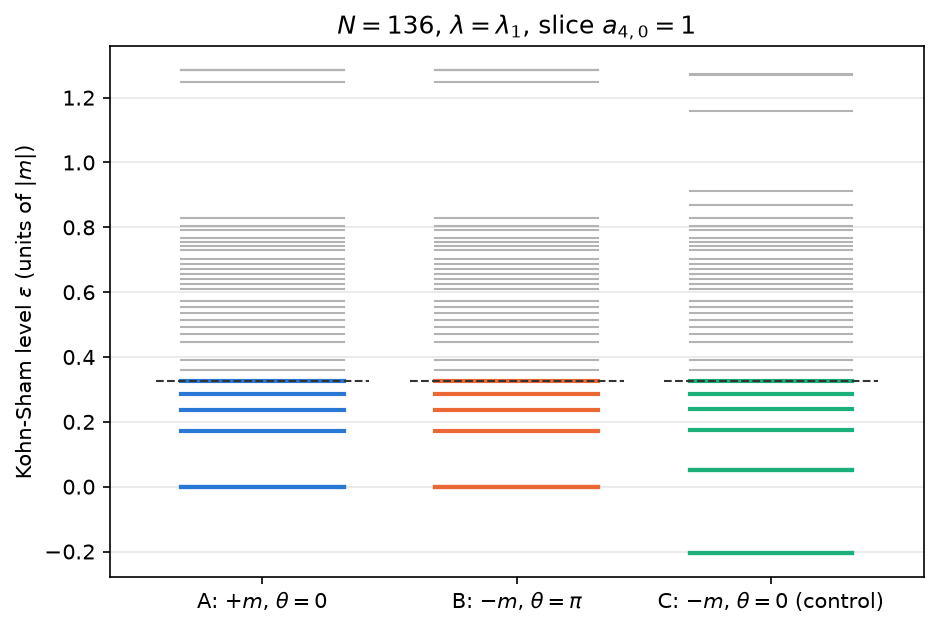

Figure 19a.1 saved as Revision/textbook/figures/19a_1_level_ladder.png


In [11]:
fig, ax = plt.subplots(figsize=(7.0, 4.6))
for x, kind in enumerate("ABC"):
    state = SELF[(136, kind)]
    for lv in state["levels"]:
        if lv[4] > 1.3:
            continue  # only the lower part of the spectrum
        full = lv[6] > 0.5  # occupied?
        ax.plot([x - 0.32, x + 0.32], [lv[4], lv[4]],
                color=COLOUR[kind] if full else "0.7", lw=2.0 if full else 1.0)
    ax.plot([x - 0.42, x + 0.42], [state["mu_or_fermi_level"]] * 2, color="0.2",
            ls="--", lw=1.0)
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(["A: $+m$, $\\theta = 0$", "B: $-m$, $\\theta = \\pi$",
                    "C: $-m$, $\\theta = 0$ (control)"])
ax.set_xlim(-0.6, 2.6)
ax.set_ylabel("Kohn-Sham level $\\varepsilon$ (units of $|m|$)")
ax.set_title("$N = 136$, $\\lambda = \\lambda_1$, slice $a_{4,0} = 1$")
ax.grid(axis="x", visible=False)
save_figure(fig, "level_ladder",
            "Level ladders of the three universes A (bare mass $+m$, tip angle 0), B "
            "(bare mass $-m$, the same coupling, tip angle $\\pi$: the T3 partner) "
            "and C (bare mass $-m$, tip angle 0: the control) for $N = 136$ "
            "particles, $\\lambda = \\lambda_1$, slice $a_{4,0} = 1$, all solved "
            "independently by the Rust solver. Each short line is one Kohn-Sham "
            "level (vertical axis, units of $|m|$), coloured when occupied and grey "
            "when empty; the dashed line is the Fermi level. A and B are the same "
            "ladder; C, with the untransformed tip, is a different one.")

The next cell draws the level-by-level differences on a logarithmic axis: for the
$i$-th level of the sorted lists, $|\varepsilon_{A,i} - \varepsilon_{B,i}|$ (A
against its partner) and $|\varepsilon_{A,i} - \varepsilon_{C,i}|$ (A against the
control). A difference that is exactly zero cannot be drawn on a logarithmic axis;
it is drawn at $10^{-17}$. The cell checks the two ranges that the caption states.

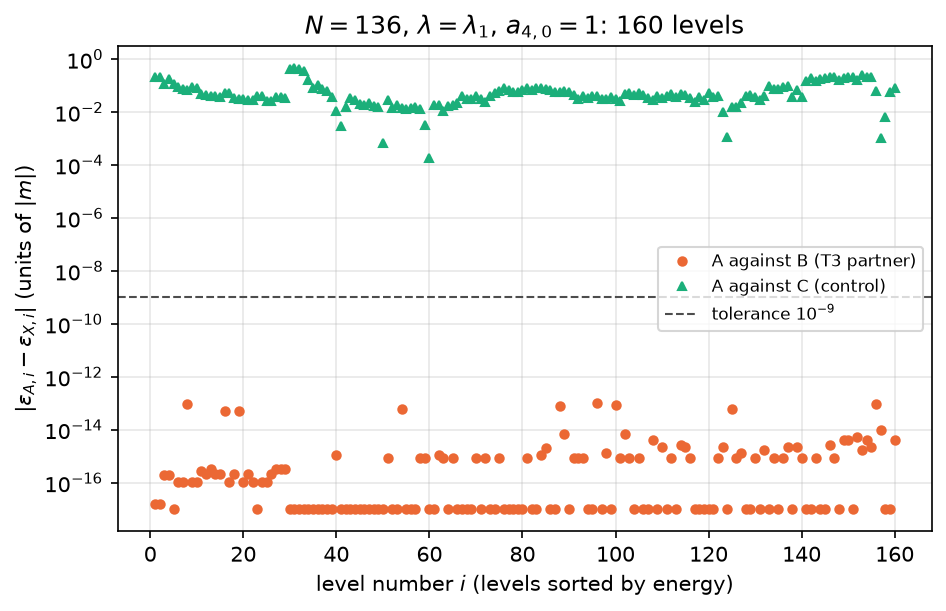

Figure 19a.2 saved as Revision/textbook/figures/19a_2_level_differences.png
RESULT largest level difference A - B = 9.86e-14
RESULT smallest and largest level difference A - C = 1.88e-04 and 0.456
PASS levels: A - B below 1e-12, A - C between 1e-4 and 1 (the caption's ranges)


In [12]:
FLOOR = 1e-17  # where exact zeros are drawn on the logarithmic axis
eps = {kind: np.array([e for e, g, f in sorted_levels(SELF[(136, kind)])])
       for kind in "ABC"}
index = np.arange(1, len(eps["A"]) + 1)
fig, ax = plt.subplots()
ax.semilogy(index, np.maximum(np.abs(eps["A"] - eps["B"]), FLOOR), "o",
            color=COLOUR["B"], ms=4, label="A against B (T3 partner)")
ax.semilogy(index, np.maximum(np.abs(eps["A"] - eps["C"]), FLOOR), "^",
            color=COLOUR["C"], ms=4, label="A against C (control)")
ax.axhline(TOL, color="0.3", ls="--", lw=1.0, label="tolerance $10^{-9}$")
ax.set_xlabel("level number $i$ (levels sorted by energy)")
ax.set_ylabel("$|\\varepsilon_{A,i} - \\varepsilon_{X,i}|$ (units of $|m|$)")
ax.set_title("$N = 136$, $\\lambda = \\lambda_1$, $a_{4,0} = 1$: 160 levels")
ax.legend(fontsize=8, loc="center right")
save_figure(fig, "level_differences",
            "Level-by-level differences between universe A and its T3 partner B "
            "(orange circles) and between A and the control C (aqua triangles), "
            "for $N = 136$, $\\lambda = \\lambda_1$, $a_{4,0} = 1$; horizontal axis "
            "the number of the level in the sorted list, vertical axis the absolute "
            "difference in units of $|m|$ (logarithmic; exact zeros drawn at "
            "$10^{-17}$). The partner agrees to $10^{-13}$ or better, the rounding "
            "of the computer, far below the tolerance $10^{-9}$ (dashed); the "
            "control differs by $10^{-4}$ to $1$.")
max_partner = float(np.max(np.abs(eps["A"] - eps["B"])))
gaps_control = np.abs(eps["A"] - eps["C"])
report("largest level difference A - B", f"{max_partner:.2e}")
report("smallest and largest level difference A - C",
       f"{gaps_control.min():.2e} and {gaps_control.max():.3g}")
check(max_partner < 1e-12 and 1e-4 < gaps_control.min() and gaps_control.max() < 1,
      "levels: A - B below 1e-12, A - C between 1e-4 and 1 (the caption's ranges)")

## 11. The densities and the potentials, point by point

T3 says that the particle density $n(y)$ and the potential $v_v(y)$ of B are those
of A, while the scalar density $S(y)$, the density $Q(y)$ and the effective mass
$M_{eff}(y)$ change sign. The next cell checks this at the 151 points of the
profiles for $N = 8$ and $N = 136$ (relative to the largest value of each column)
and also checks the interaction energy density $e_{int}$, which contains $S$ only as
$S^2$.

In [13]:
EVEN = ("n", "v_v", "e_int", "rho", "p3", "p_t", "p8")  # unchanged by the map
ODD = ("S", "Q", "M_eff")  # change sign under the map


def profile_mismatch(first, second):
    """Largest relative mismatch of the T3 rule (even columns equal, odd opposite)."""
    worst = 0.0
    for column in EVEN + ODD:
        sign = -1.0 if column in ODD else 1.0
        a, b = first["profile"][column], second["profile"][column]
        scale = max(float(np.max(np.abs(a))), 1e-300)
        worst = max(worst, float(np.max(np.abs(b - sign * a))) / scale)
    return worst


for N in (8, 136):
    mismatch = profile_mismatch(SELF[(N, "A")], SELF[(N, "B")])
    control = profile_mismatch(SELF[(N, "A")], SELF[(N, "C")])
    say(f"N = {N}: T3 rule for B: {mismatch:.2e}; the same rule for C: {control:.3g}")
    check(mismatch < TOL and control > 0.1,
          f"N = {N}: n, v_v, e_int, rho, p3, p_t, p8 equal; S, Q, M_eff opposite",
          record="Revision/pairing/kohn_sham/t3-theory.json, statements S3 and S4")

N = 8: T3 rule for B: 2.78e-15; the same rule for C: 298
PASS N = 8: n, v_v, e_int, rho, p3, p_t, p8 equal; S, Q, M_eff opposite
     reproduces Revision/pairing/kohn_sham/t3-theory.json, statements S3 and S4
N = 136: T3 rule for B: 5.80e-15; the same rule for C: 4.65e+03
PASS N = 136: n, v_v, e_int, rho, p3, p_t, p8 equal; S, Q, M_eff opposite
     reproduces Revision/pairing/kohn_sham/t3-theory.json, statements S3 and S4


The next cell draws the densities for $N = 136$. Left: the proper particle density
$n(y)$ (logarithmic axis) of A, B and C; A and B lie on top of each other (B is
dashed). Right: the scalar density $S(y)$ of A and B; B is the mirror image of A,
$S_B = -S_A$. The scalar density of the control C is not drawn on the right: it is
more than ten times larger (the cell prints and checks the factor) and would flatten
the two curves that matter.

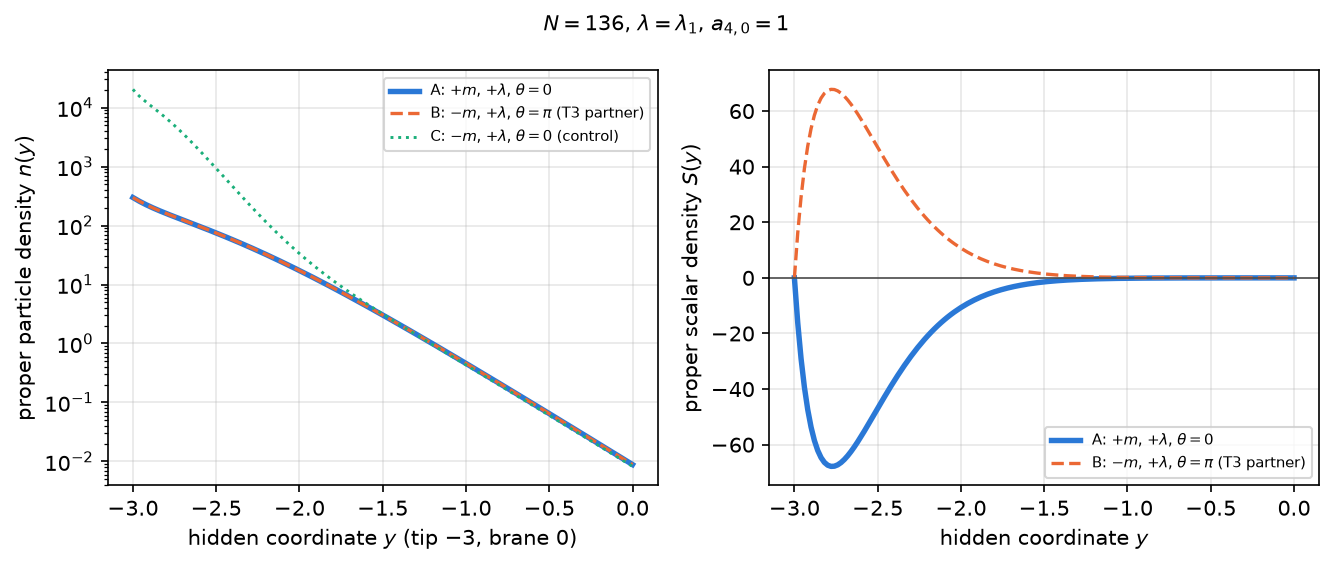

Figure 19a.3 saved as Revision/textbook/figures/19a_3_density_profiles.png
RESULT largest |S| of C divided by largest |S| of A = 24.1
PASS the scalar density of the control is more than ten times that of A


In [14]:
y = SELF[(136, "A")]["profile"]["y"]  # the 151 points from the tip to the brane
fig, (left, right) = plt.subplots(1, 2, figsize=(9.0, 3.8))
STYLE = {"A": dict(lw=2.6), "B": dict(lw=1.6, ls="--"), "C": dict(lw=1.4, ls=":")}
for kind in "ABC":
    prof = SELF[(136, kind)]["profile"]
    left.semilogy(y, prof["n"], color=COLOUR[kind], label=NAME[kind], **STYLE[kind])
    if kind != "C":
        right.plot(y, prof["S"], color=COLOUR[kind], label=NAME[kind],
                   **STYLE[kind])
left.set_xlabel("hidden coordinate $y$ (tip $-3$, brane $0$)")
left.set_ylabel("proper particle density $n(y)$")
left.legend(fontsize=7, loc="upper right")
right.set_xlabel("hidden coordinate $y$")
right.set_ylabel("proper scalar density $S(y)$")
right.axhline(0.0, color="0.3", lw=0.8)
right.legend(fontsize=7, loc="lower right")
fig.suptitle("$N = 136$, $\\lambda = \\lambda_1$, $a_{4,0} = 1$", fontsize=10)
fig.tight_layout()
save_figure(fig, "density_profiles",
            "Left: the proper particle density $n(y)$ of the universes A (blue), B "
            "(orange, dashed) and C (aqua, dotted) for $N = 136$, "
            "$\\lambda = \\lambda_1$, $a_{4,0} = 1$, against the hidden coordinate $y$ "
            "from the tip $y = -3$ to the brane $y = 0$ (logarithmic vertical axis, "
            "units $|m|^7$). Right: the proper scalar density $S(y)$ of A and B. "
            "The density of B is that of A, and its scalar density is the mirror "
            "image $S_B = -S_A$, as T3 states. The control C has its own densities; "
            "its scalar density, more than ten times larger, is not drawn.")
size = {kind: float(np.max(np.abs(SELF[(136, kind)]["profile"]["S"])))
        for kind in "AC"}
factor = size["C"] / size["A"]  # how much larger the control's scalar density is
report("largest |S| of C divided by largest |S| of A", f"{factor:.1f}")
check(factor > 10.0,
      "the scalar density of the control is more than ten times that of A")

The next cell draws the effective mass $M_{eff}(y) = \pm m + \frac{15}{16}\lambda S$
(left) and the potential $v_v(y) = -\frac{1}{16}\lambda n$ (right) of A, B and C.
For B the mass is $-M_{eff}$ of A at every point; the potential is the same.

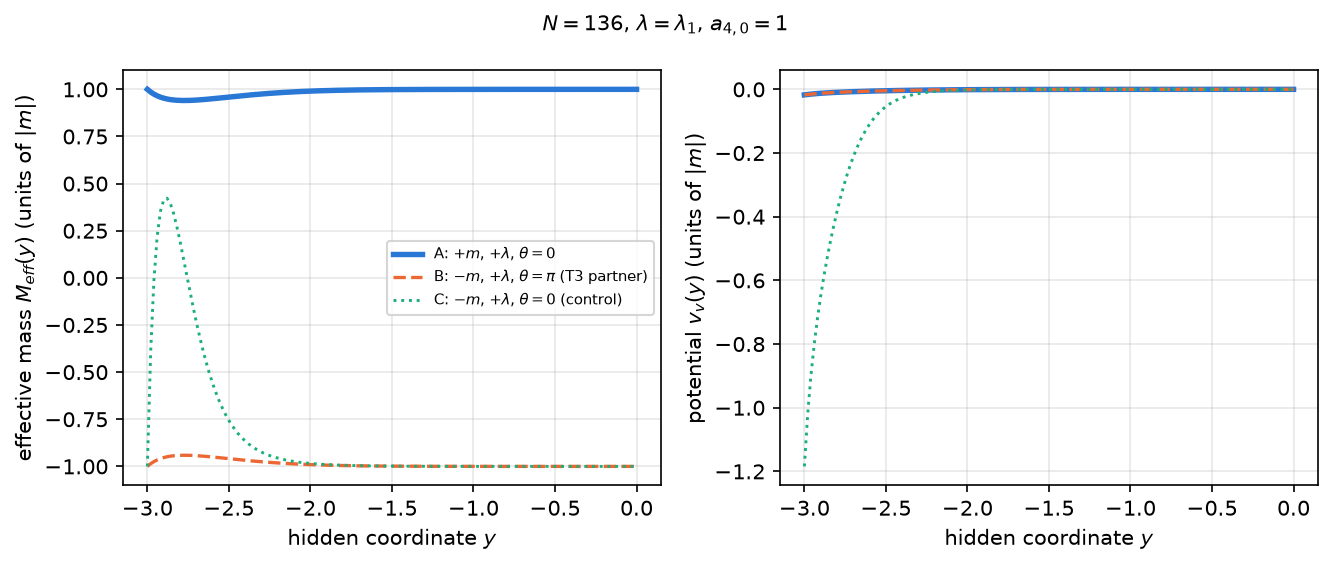

Figure 19a.4 saved as Revision/textbook/figures/19a_4_mass_and_potential.png


In [15]:
fig, (left, right) = plt.subplots(1, 2, figsize=(9.0, 3.8))
for kind in "ABC":
    prof = SELF[(136, kind)]["profile"]
    left.plot(y, prof["M_eff"], color=COLOUR[kind], label=NAME[kind], **STYLE[kind])
    right.plot(y, prof["v_v"], color=COLOUR[kind], label=NAME[kind], **STYLE[kind])
left.set_xlabel("hidden coordinate $y$")
left.set_ylabel("effective mass $M_{eff}(y)$ (units of $|m|$)")
left.legend(fontsize=7, loc="center right")
right.set_xlabel("hidden coordinate $y$")
right.set_ylabel("potential $v_v(y)$ (units of $|m|$)")
fig.suptitle("$N = 136$, $\\lambda = \\lambda_1$, $a_{4,0} = 1$", fontsize=10)
fig.tight_layout()
save_figure(fig, "mass_and_potential",
            "Left: the self-consistent effective mass $M_{eff}(y)$ of A (blue), B "
            "(orange, dashed) and C (aqua, dotted) for $N = 136$, "
            "$\\lambda = \\lambda_1$, $a_{4,0} = 1$ (units of $|m|$). Right: the "
            "self-consistent potential $v_v(y)$ (units of $|m|$). B has exactly the "
            "opposite mass of A at every point and the same potential: this is why "
            "the bare mass must change sign while the coupling keeps its sign. The "
            "control C has the mass $-m$ but its own, different mean field.")

## 12. The energy-momentum profiles

The energy density and the three pressures are the source terms that the gravity
equations would need. The next cell draws $\rho$, $p_3$, $p_t$ and $p_8$ for
$N = 136$, each multiplied by the volume factor $e^{6Hy}$ (so the area under each
curve is proportional to the integral over the hidden direction). The cell also
checks the identity $p_8' + 6Hp_8 = 3H(p_3 + p_t)$ (the conservation law along
$y$), which the solver measures for every state, for B.

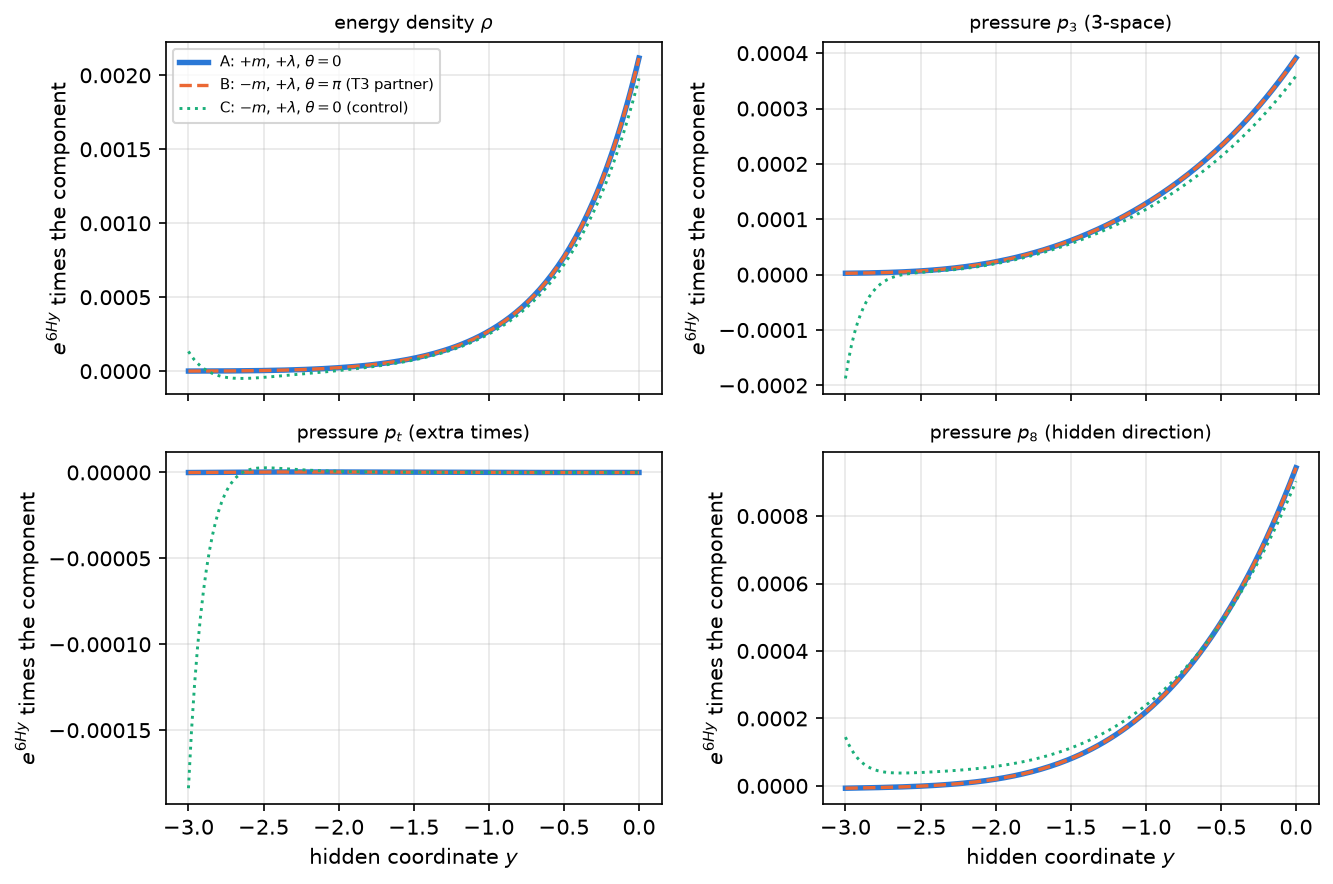

Figure 19a.5 saved as Revision/textbook/figures/19a_5_emt_profiles.png
N = 8, B: y-conservation, integrated 3.9e-13, pointwise 2.2e-09 (relative)
PASS N = 8: the partner B obeys p8' + 6H p8 = 3H (p3 + p_t)
     reproduces Revision/kohn_sham/reports/ks-rust-solver.json, checks
    emt_y_conservation_integrated, pointwise
N = 136, B: y-conservation, integrated 1.7e-12, pointwise 8.4e-11 (relative)
PASS N = 136: the partner B obeys p8' + 6H p8 = 3H (p3 + p_t)
     reproduces Revision/kohn_sham/reports/ks-rust-solver.json, checks
    emt_y_conservation_integrated, pointwise


In [16]:
weight = np.exp(6.0 * y)  # the proper-volume factor e^{6 H y}, H = 1
fig, axes = plt.subplots(2, 2, figsize=(9.0, 6.0), sharex=True)
for ax, column, title in zip(axes.flat, ("rho", "p3", "p_t", "p8"),
                             ("energy density $\\rho$", "pressure $p_3$ (3-space)",
                              "pressure $p_t$ (extra times)",
                              "pressure $p_8$ (hidden direction)")):
    for kind in "ABC":
        prof = SELF[(136, kind)]["profile"]
        ax.plot(y, weight * prof[column], color=COLOUR[kind], label=NAME[kind],
                **STYLE[kind])
    ax.set_title(title, fontsize=9)
    ax.set_ylabel("$e^{6Hy}$ times the component")
for ax in axes[1]:
    ax.set_xlabel("hidden coordinate $y$")
axes[0, 0].legend(fontsize=7, loc="upper left")
fig.tight_layout()
save_figure(fig, "emt_profiles",
            "The energy-momentum profiles of A (blue), B (orange, dashed) and C "
            "(aqua, dotted) for $N = 136$, $\\lambda = \\lambda_1$, $a_{4,0} = 1$: "
            "energy density $\\rho$, pressures $p_3$ (3-space), $p_t$ (the "
            "deflating extra times) and $p_8$ (hidden direction), each times the "
            "volume factor $e^{6Hy}$, against the hidden coordinate $y$ (units "
            "$|m|^8$ with $H = 1$). The four profiles of the partner B coincide "
            "with those of A at every point (T3, statement S4); the control C "
            "differs.")
for N in (8, 136):
    B = SELF[(N, "B")]
    integrated, pointwise = (B["yConservationIntegratedRel"],
                             B["yConservationPointwiseRel"])
    say(f"N = {N}, B: y-conservation, integrated {integrated:.1e}, pointwise "
        f"{pointwise:.1e} (relative)")
    check(integrated < 1e-8 and pointwise < 1e-6,
          f"N = {N}: the partner B obeys p8' + 6H p8 = 3H (p3 + p_t)",
          record=f"{SOLVER_REPORT}, checks emt_y_conservation_integrated, pointwise")

## 13. N = 8: where the zero modes live, and a level of the control by hand

For $N = 8$ the particles sit in the eight zero modes of momentum $k = 0$. Without
interaction ($\lambda = 0$, so $M_{eff} = M = \pm m$ and $v_v = 0$) the block
equation at $k = 0$ is the first-order system $d\chi/dy = N\chi$ with
$N = M\sigma_3 + ij\varepsilon\sigma_1$ (record `ks-theory.json`), and at
$\varepsilon = 0$ it is $d\chi_1/dy = M\chi_1$, $d\chi_2/dy = -M\chi_2$. So:

- A ($M = +m$, even parity $\chi_2(0) = 0$, tip $\chi_2(-L) = 0$): $\chi_2 = 0$ and
  $\chi = (e^{my}, 0)$, largest at the brane;
- B ($M = -m$, odd parity $\chi_1(0) = 0$, tip angle $\pi$: $\chi_1(-L) = 0$):
  $\chi_1 = 0$ and $\chi = (0, e^{my})$, the T3 image $\sigma_2(e^{my}, 0) =
  (0, ie^{my})$ up to the factor $i$, again largest at the brane;
- C ($M = -m$, even parity, tip $\chi_2(-L) = 0$): $\chi = (e^{-my}, 0)$, largest
  at the TIP.

The coordinate density $e^{6Hy}n(y)$ is proportional to $|\chi|^2$, so its value at
the brane divided by its value at the tip is $e^{2mL} = e^6$ for A and B and
$e^{-2mL} = e^{-6}$ for C. The next cell solves the three $N = 8$ universes without
interaction at $a_{4,0} = 1$ (three runs) and checks these two ratios.

In [17]:
FREE8 = {kind: universe(kind, 0.0, 1.0, 8, 0.25) for kind in "ABC"}  # lambda = 0
L_TIP, M_BARE = 3.0, 1.0  # the tip distance L and the bare mass |m| of the record


def brane_over_tip(state):
    """Coordinate density e^{6Hy} n(y) at the brane divided by its value at the tip."""
    n = state["profile"]["n"]
    return float(n[-1] * weight[-1] / (n[0] * weight[0]))


expected = {"A": math.exp(2 * M_BARE * L_TIP), "B": math.exp(2 * M_BARE * L_TIP),
            "C": math.exp(-2 * M_BARE * L_TIP)}  # e^{+6}, e^{+6}, e^{-6}
ratio_error = 0.0
for kind in "ABC":
    ratio = brane_over_tip(FREE8[kind])
    ratio_error = max(ratio_error, abs(ratio / expected[kind] - 1.0))
    say(f"{kind}: brane / tip = {ratio:.6e}, closed form {expected[kind]:.6e}")
check(ratio_error < 1e-8,
      "free N = 8: the zero modes of A and B live at the brane, those of C at the tip")

A: brane / tip = 4.034288e+02, closed form 4.034288e+02
B: brane / tip = 4.034288e+02, closed form 4.034288e+02
C: brane / tip = 2.478752e-03, closed form 2.478752e-03
PASS free N = 8: the zero modes of A and B live at the brane, those of C at the tip


The control C has one more surprise: a level inside the gap $|\varepsilon| < m$.
Take the odd parity ($\chi_1(0) = 0$) with the tip condition $\chi_2(-L) = 0$, at
$k = 0$ with $M = -m$ and $v_v = 0$. Write $D$ for the derivative $d/dy$. The block
equation $D\chi = N\chi$ reads

$$D\chi_1 = -m\chi_1 + ij\varepsilon\chi_2,\qquad
D\chi_2 = ij\varepsilon\chi_1 + m\chi_2 .$$

Differentiate the second equation: $D^2\chi_2 = ij\varepsilon D\chi_1 + mD\chi_2$.
Insert the first equation: $D^2\chi_2 = ij\varepsilon(-m\chi_1 +
ij\varepsilon\chi_2) + mD\chi_2 = -m(ij\varepsilon\chi_1) - \varepsilon^2\chi_2 +
mD\chi_2$ (because $i^2j^2 = -1$). The second equation says $ij\varepsilon\chi_1 =
D\chi_2 - m\chi_2$; insert it: $D^2\chi_2 = -mD\chi_2 + m^2\chi_2 -
\varepsilon^2\chi_2 + mD\chi_2 = (m^2 - \varepsilon^2)\chi_2$. For
$|\varepsilon| < m$ write $q = \sqrt{m^2 - \varepsilon^2}$; the solution with
$\chi_2(-L) = 0$ is $\chi_2 = \sinh(q(y + L))$, because $D^2\sinh(q(y + L)) =
q^2\sinh(q(y + L))$ and $\sinh 0 = 0$. The brane condition $\chi_1(0) = 0$ is
$D\chi_2(0) - m\chi_2(0) = 0$, that is $q\cosh(qL) = m\sinh(qL)$, or

$$\tanh(qL) = q/m .$$

The function $\tanh(qL) - q/m$ is $0$ at $q = 0$, positive just above $0$ (its slope
there is $L - 1/m = 2$) and negative at $q = m$, so it has a root in $(0, m)$; the
level is $\varepsilon_b = \sqrt{m^2 - q^2} = m/\cosh(qL)$ (since $q/m = \tanh(qL)$
and $1 - \tanh^2 = 1/\cosh^2$). For A ($M = +m$) the same steps give
$q\cosh(qL) = -m\sinh(qL)$, which has no root with $q > 0$: A has no level in the
gap in this sector. The next cell finds $q$ by **bisection** (halve an interval
that contains the root, keep the half where the function changes sign, 200 times)
and checks: the Kohn-Sham gap of the free control C is $\varepsilon_b$; the gaps of
A and B are equal to each other and to the gap of the committed state
`N8_lam0_a10`.

In [18]:
def bound_state_q(m, L):
    """The root q in (0, m) of tanh(q L) - q / m, by bisection."""
    low, high = 0.5 * m, m  # the function is positive at m/2 and negative at m
    for _ in range(200):
        middle = 0.5 * (low + high)
        if math.tanh(middle * L) - middle / m > 0.0:
            low = middle  # the root lies above the middle
        else:
            high = middle  # the root lies below the middle
    return 0.5 * (low + high)


q_root = bound_state_q(M_BARE, L_TIP)
eps_b = M_BARE / math.cosh(q_root * L_TIP)  # the level inside the gap
report("q of the control's sub-gap level", f"{q_root:.12f}")
report("sub-gap level eps_b = m / cosh(q L)", f"{eps_b:.12f}", "|m|")
gap = {}
for kind in "ABC":
    homo, lumo = homo_lumo(FREE8[kind])
    gap[kind] = lumo - homo
    say(f"{kind}: HOMO {homo:.3e}, LUMO {lumo:.12f}, Kohn-Sham gap {gap[kind]:.12f}")
recorded = float(summary["N8_lam0_a10"]["KS_gap"])
same_level = abs(math.sqrt(M_BARE ** 2 - q_root ** 2) - eps_b) < 1e-12  # two forms
check(abs(gap["C"] - eps_b) < 1e-9 and same_level,
      "the free control has the Kohn-Sham gap m/cosh(qL) of the sub-gap level")
check(close(gap["A"], recorded) and close(gap["B"], gap["A"]),
      "the free A and B have the gap of the committed state N8_lam0_a10",
      record=f"{GROUND}/summary.csv, N8_lam0_a10, column KS_gap")

RESULT q of the control's sub-gap level = 0.994901528453
RESULT sub-gap level eps_b = m / cosh(q L) = 0.100851121375 |m|
A: HOMO 0.000e+00, LUMO 0.170349251323, Kohn-Sham gap 0.170349251323
B: HOMO 0.000e+00, LUMO 0.170349251323, Kohn-Sham gap 0.170349251323
C: HOMO 0.000e+00, LUMO 0.100851121375, Kohn-Sham gap 0.100851121375
PASS the free control has the Kohn-Sham gap m/cosh(qL) of the sub-gap level
PASS the free A and B have the gap of the committed state N8_lam0_a10
     reproduces Revision/kohn_sham/results/ground/summary.csv, N8_lam0_a10, column KS_gap


The next cell draws the coordinate density $e^{6Hy}n(y)$ of the three $N = 8$
universes: left without interaction (the thin black dotted lines are the closed
forms $e^{\pm 2my}$, scaled to the brane value), right with the coupling
$\lambda_1$ (the states of section 8). With the interaction, A and B keep their
shape, while the control's zero modes near the tip, where the proper density is
huge, feel a strong mean field and are pushed away from the very end.

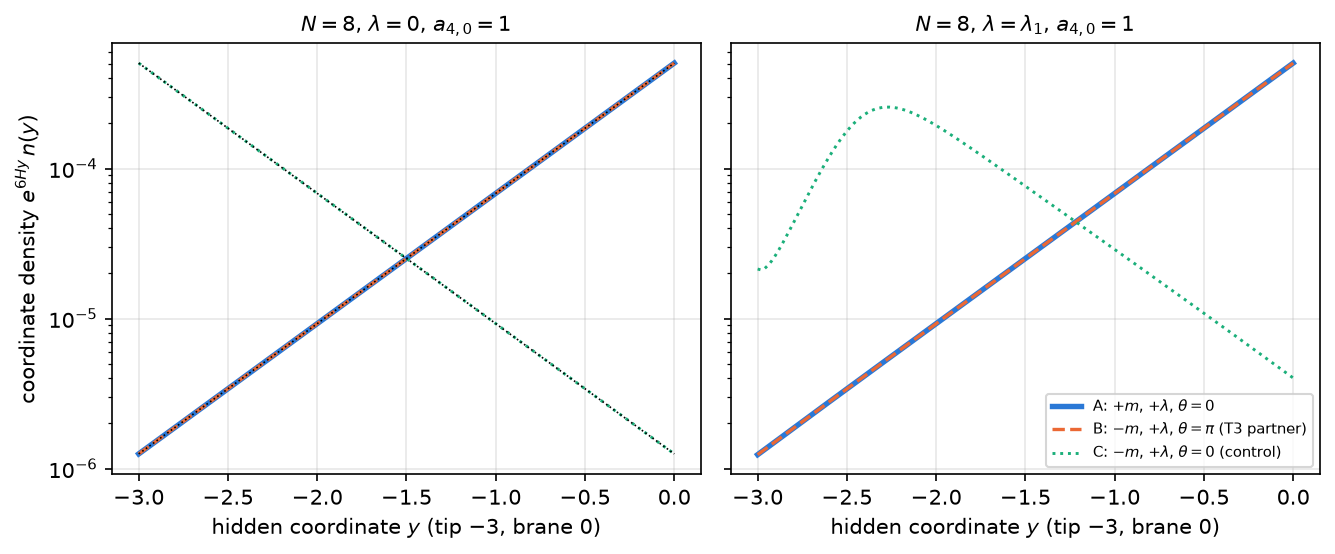

Figure 19a.6 saved as Revision/textbook/figures/19a_6_zero_modes_n8.png


In [19]:
fig, (left, right) = plt.subplots(1, 2, figsize=(9.0, 3.8), sharey=True)
for kind in "ABC":
    left.semilogy(y, weight * FREE8[kind]["profile"]["n"], color=COLOUR[kind],
                  label=NAME[kind], **STYLE[kind])
    right.semilogy(y, weight * SELF[(8, kind)]["profile"]["n"], color=COLOUR[kind],
                   label=NAME[kind], **STYLE[kind])
top = {kind: float(weight[-1] * FREE8[kind]["profile"]["n"][-1]) for kind in "AC"}
left.semilogy(y, top["A"] * np.exp(2 * M_BARE * y), "k:", lw=0.8)  # e^{2 m y}
left.semilogy(y, top["C"] * np.exp(-2 * M_BARE * y), "k:", lw=0.8)  # e^{-2 m y}
left.set_title("$N = 8$, $\\lambda = 0$, $a_{4,0} = 1$", fontsize=10)
right.set_title("$N = 8$, $\\lambda = \\lambda_1$, $a_{4,0} = 1$", fontsize=10)
left.set_ylabel("coordinate density $e^{6Hy}\\,n(y)$")
for ax in (left, right):
    ax.set_xlabel("hidden coordinate $y$ (tip $-3$, brane $0$)")
right.legend(fontsize=7, loc="lower right")
fig.tight_layout()
save_figure(fig, "zero_modes_n8",
            "The coordinate particle density $e^{6Hy}n(y)$ (particles per unit of "
            "$y$; logarithmic vertical axis) of the $N = 8$ universes A (blue), B "
            "(orange, dashed) and C (aqua, dotted) at $a_{4,0} = 1$, against the "
            "hidden coordinate $y$ from the tip $-3$ to the brane $0$. Left: without "
            "interaction; the thin black dotted lines are the closed forms "
            "$e^{2my}$ and $e^{-2my}$. A and B hold their particles in zero modes "
            "at the brane; with the untransformed tip (C) the zero modes sit at the "
            "tip. Right: with the coupling $\\lambda_1$; A and B are unchanged in "
            "shape, the control is reshaped by its strong mean field near the tip.")

## 14. T3 along the deflating history

T3 holds at every slice of the history, because the slice $a_{4,0}$ enters only
through $\kappa = e^{-Hy - a_{4,0}}$, which the map does not touch. The next cell
solves A, B and C at the five slices $a_{4,0} = 0, 0.5, 1, 1.5, 2$ for $N = 136$
and $N = 688$, each with its coupling $\lambda_1$ (27 new runs; the slice
$a_{4,0} = 1$ of $N = 136$ was solved above), and checks at every slice: A
reproduces the energy of the record; B has the levels, profiles and energy of A
(relative energy difference below $10^{-13}$); C differs from A by $0.5$ to $10$
percent.

In [20]:
SLICES = [0.0, 0.5, 1.0, 1.5, 2.0]
HIST = {}  # (N, kind, a4) -> state
for N in (136, 688):
    for a4 in SLICES:
        for kind in "ABC":
            if N == 136 and a4 == 1.0:
                HIST[(N, kind, a4)] = SELF[(N, kind)]  # already solved
            else:
                HIST[(N, kind, a4)] = universe(kind, LAMBDA[N][0], a4, N, 0.45)
ok_record, ok_partner, ok_control = True, True, True
partner_rel, control_pct = [], []  # relative differences A - B, percents A - C
for N in (136, 688):
    for a4 in SLICES:
        A, B, C = (HIST[(N, kind, a4)] for kind in "ABC")
        record_energy = float(summary[f"N{N}_lamp1_a{round(10 * a4):02d}"]["E_KS"])
        ok_record &= close(A["E_KS"], record_energy)
        partner_rel.append(abs(A["E_KS"] - B["E_KS"]) / abs(A["E_KS"]))
        control_pct.append(100.0 * abs(A["E_KS"] - C["E_KS"]) / abs(A["E_KS"]))
        ok_partner &= level_difference(A, B) < TOL and profile_mismatch(A, B) < TOL
        E_A, E_B, E_C = A["E_KS"], B["E_KS"], C["E_KS"]
        say(f"N = {N:3d}, a4,0 = {a4:3.1f}: E_KS A {E_A:.10f}, "
            f"B {E_B:.10f}, C {E_C:.6f}")
report("largest relative E_KS difference A - B", f"{max(partner_rel):.1e}")
report("relative E_KS difference A - C", f"{min(control_pct):.1f} to "
       f"{max(control_pct):.1f}", "percent")
check(ok_record, "A reproduces the recorded E_KS at all 10 states of the history",
      record=f"{GROUND}/summary.csv, N136_lamp1_a00 to a20, N688_lamp1_a00 to a20")
check(ok_partner and max(partner_rel) < 1e-13,
      "B has the levels, energy and profiles of A at every slice")
check(0.5 < min(control_pct) and max(control_pct) < 10.0,
      "the control C differs from A by 0.5 to 10 percent at every slice")

N = 136, a4,0 = 0.0: E_KS A 80.2837009244, B 80.2837009244, C 73.179866
N = 136, a4,0 = 0.5: E_KS A 51.2491613321, B 51.2491613321, C 46.475561
N = 136, a4,0 = 1.0: E_KS A 32.3929491532, B 32.3929491532, C 29.283751
N = 136, a4,0 = 1.5: E_KS A 20.2130306754, B 20.2130306754, C 18.533932
N = 136, a4,0 = 2.0: E_KS A 12.4470595905, B 12.4470595905, C 12.175574
N = 688, a4,0 = 0.0: E_KS A 680.4447575708, B 680.4447575708, C 670.715818
N = 688, a4,0 = 0.5: E_KS A 437.5215029073, B 437.5215029073, C 431.359438
N = 688, a4,0 = 1.0: E_KS A 279.4468465636, B 279.4468465636, C 275.745397
N = 688, a4,0 = 1.5: E_KS A 176.7808903556, B 176.7808903556, C 175.297541
N = 688, a4,0 = 2.0: E_KS A 110.4456550192, B 110.4456550192, C 112.097612
RESULT largest relative E_KS difference A - B = 4.0e-14
RESULT relative E_KS difference A - C = 0.8 to 9.6 percent
PASS A reproduces the recorded E_KS at all 10 states of the history
     reproduces Revision/kohn_sham/results/ground/summary.csv, N136_lamp1_a00 to a

The next cell draws the Kohn-Sham energy along the history. As the extra times
deflate and 3-space inflates, every 3-momentum is redshifted and the energy of the
gas falls; A and B fall together, the control C on its own curve.

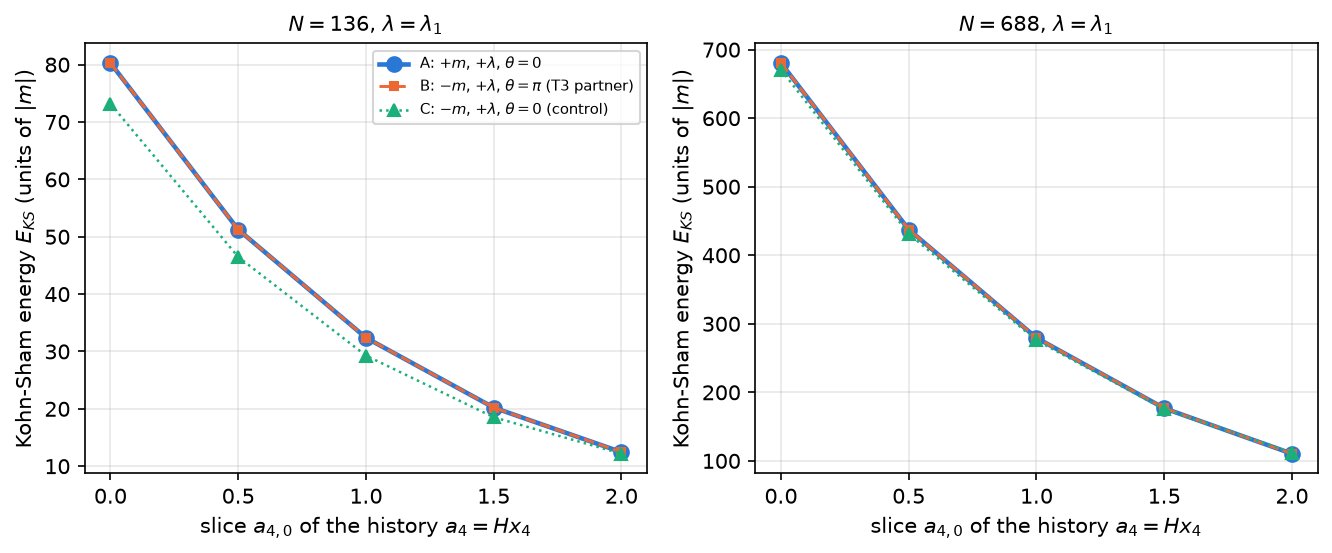

Figure 19a.7 saved as Revision/textbook/figures/19a_7_history_energy.png


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(9.0, 3.8))
MARK = {"A": dict(marker="o", ms=7, lw=2.2), "B": dict(marker="s", ms=4, lw=1.4,
                                                       ls="--"),
        "C": dict(marker="^", ms=6, lw=1.2, ls=":"),
        "D": dict(marker="D", ms=5, lw=1.4)}
for ax, N in zip(axes, (136, 688)):
    for kind in "ABC":
        ax.plot(SLICES, [HIST[(N, kind, a4)]["E_KS"] for a4 in SLICES],
                color=COLOUR[kind], label=NAME[kind], **MARK[kind])
    ax.set_xlabel("slice $a_{4,0}$ of the history $a_4 = Hx_4$")
    ax.set_ylabel("Kohn-Sham energy $E_{KS}$ (units of $|m|$)")
    ax.set_title(f"$N = {N}$, $\\lambda = \\lambda_1$", fontsize=10)
axes[0].legend(fontsize=7, loc="upper right")
fig.tight_layout()
save_figure(fig, "history_energy",
            "The Kohn-Sham energy $E_{KS}$ (units of $|m|$) of A (blue circles), B "
            "(orange squares, dashed) and C (aqua triangles, dotted) at the five "
            "slices $a_{4,0} = 0$ to $2$ of the deflating history, for $N = 136$ "
            "(left) and $N = 688$ (right) at the coupling $\\lambda_1$ of each $N$. "
            "The energy falls because the 3-momenta are redshifted as 3-space "
            "inflates and the extra times deflate; the T3 partner B follows A at "
            "every slice, the control C does not.")

The next cell draws the same comparison as relative differences on a logarithmic
axis: $|E_A - E_B|/|E_A|$ (partner) and $|E_A - E_C|/|E_A|$ (control) at every
slice, for both particle numbers.

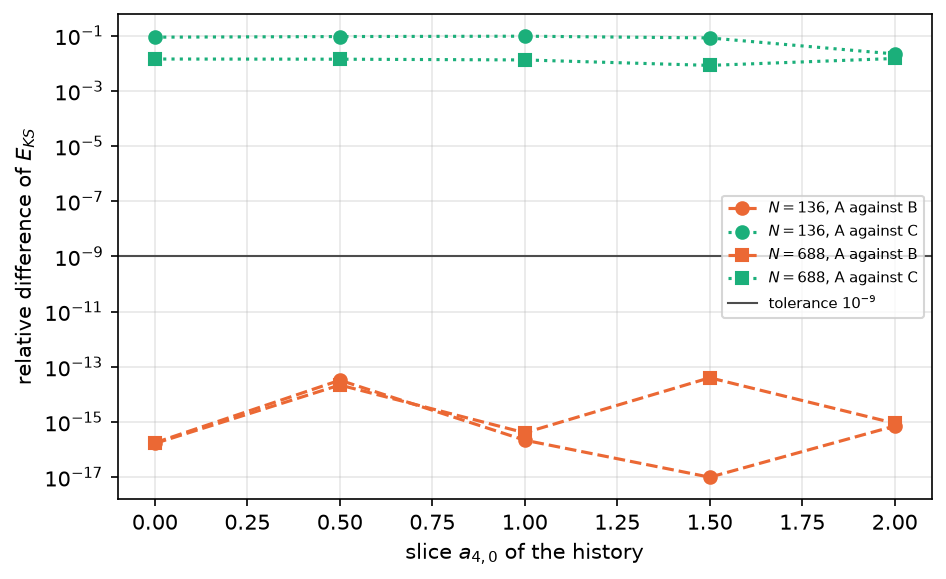

Figure 19a.8 saved as Revision/textbook/figures/19a_8_history_agreement.png


In [22]:
fig, ax = plt.subplots()
for N, marker in ((136, "o"), (688, "s")):
    for kind in "BC":
        values = [max(abs(HIST[(N, "A", a4)]["E_KS"] - HIST[(N, kind, a4)]["E_KS"])
                      / abs(HIST[(N, "A", a4)]["E_KS"]), FLOOR) for a4 in SLICES]
        ax.semilogy(SLICES, values, marker=marker, color=COLOUR[kind],
                    ls="--" if kind == "B" else ":",
                    label=f"$N = {N}$, A against {kind}")
ax.axhline(TOL, color="0.3", lw=1.0, label="tolerance $10^{-9}$")
ax.set_xlabel("slice $a_{4,0}$ of the history")
ax.set_ylabel("relative difference of $E_{KS}$")
ax.legend(fontsize=7, loc="center right")
save_figure(fig, "history_agreement",
            "Relative differences of the Kohn-Sham energy between A and its T3 "
            "partner B (orange) and between A and the control C (aqua) at the five "
            "slices of the history, for $N = 136$ (circles) and $N = 688$ (squares); "
            "logarithmic vertical axis, exact zeros drawn at $10^{-17}$. The "
            "partner agrees to better than $10^{-13}$ at every slice: T3 holds slice "
            "by slice along the deflating history. The control is off by $0.5$ to "
            "$10$ percent.")

## 15. The coupling must keep its sign

T3 pairs $(m, \lambda)$ with $(-m, +\lambda)$. What about $(-m, -\lambda)$, the
parameter change of the classical theorem T1? The next cell solves, for $N = 136$ at
$a_{4,0} = 1$, the five couplings $\lambda = -\lambda_2, -\lambda_1, 0, +\lambda_1,
+\lambda_2$ for all four universes A, B, C, D (with the record's margins $0.85$,
$0.45$, $0.25$). It checks: A reproduces the record at every coupling; B equals A;
D at $\lambda$ equals A at $-\lambda$ (that is T3 applied to the state with
$-\lambda$), so D differs from A whenever $\lambda \ne 0$; C differs from A by $1$
to $3.5$ at every coupling.

In [23]:
l1, l2 = LAMBDA[136]
COUPLINGS = [("lamm2", -l2, 0.85), ("lamm1", -l1, 0.45), ("lam0", 0.0, 0.25),
             ("lamp1", l1, 0.45), ("lamp2", l2, 0.85)]  # tag, lambda, margin
SCAN = {}  # (tag, kind) -> state
for tag, lam, margin in COUPLINGS:
    for kind in "ABCD":
        if tag == "lamp1" and kind in "ABC":
            SCAN[(tag, kind)] = SELF[(136, kind)]  # already solved
        else:
            SCAN[(tag, kind)] = universe(kind, lam, 1.0, 136, margin)
MIRROR = {"lamm2": "lamp2", "lamm1": "lamp1", "lam0": "lam0", "lamp1": "lamm1",
          "lamp2": "lamm2"}  # the tag of -lambda
ok_record, ok_partner, ok_mirror, ok_wrong = True, True, True, True
control_gap = []  # |E_C - E_A| at each coupling
for tag, lam, margin in COUPLINGS:
    E = {kind: SCAN[(tag, kind)]["E_KS"] for kind in "ABCD"}
    ok_record &= close(E["A"], float(summary[f"N136_{tag}_a10"]["E_KS"]))
    ok_partner &= close(E["A"], E["B"]) and level_difference(
        SCAN[(tag, "A")], SCAN[(tag, "B")]) < TOL
    ok_mirror &= close(E["D"], SCAN[(MIRROR[tag], "A")]["E_KS"])
    ok_wrong &= (lam == 0.0) or abs(E["D"] - E["A"]) > 1e-4
    control_gap.append(abs(E["C"] - E["A"]))
    E_A, E_B, E_C, E_D = (E[kind] for kind in "ABCD")
    say(f"lambda = {lam:+.4e}: A {E_A:.10f}  B {E_B:.10f}  "
        f"C {E_C:.6f}  D {E_D:.10f}")
check(ok_record, "A reproduces the recorded E_KS for all five couplings",
      record=f"{GROUND}/summary.csv, N136_lamm2_a10 to N136_lamp2_a10")
check(ok_partner, "B = A for every coupling: the partner keeps +lambda")
check(ok_mirror and ok_wrong,
      "D(lambda) = A(-lambda), so (-m, -lambda) is not the partner for lambda != 0",
      record="Revision/pairing/kohn_sham/reports/python-t3.json, check "
             "T3.mean_field_map (control)")
check(1.0 < min(control_gap) and max(control_gap) < 3.5,
      "the control C differs from A by 1 to 3.5 at every coupling")

lambda = -2.7890e-03: A 32.3593734113  B 32.3593734113  C 34.540794  D 32.4116192324
lambda = -9.2980e-04: A 32.3755880337  B 32.3755880337  C 33.529490  D 32.3929491532
lambda = +0.0000e+00: A 32.3841156874  B 32.3841156874  C 30.731389  D 32.3841156874
lambda = +9.2980e-04: A 32.3929491532  B 32.3929491532  C 29.283751  D 32.3755880337
lambda = +2.7890e-03: A 32.4116192324  B 32.4116192324  C 28.980584  D 32.3593734113
PASS A reproduces the recorded E_KS for all five couplings
     reproduces Revision/kohn_sham/results/ground/summary.csv, N136_lamm2_a10 to
    N136_lamp2_a10
PASS B = A for every coupling: the partner keeps +lambda
PASS D(lambda) = A(-lambda), so (-m, -lambda) is not the partner for lambda != 0
     reproduces Revision/pairing/kohn_sham/reports/python-t3.json, check
    T3.mean_field_map (control)
PASS the control C differs from A by 1 to 3.5 at every coupling


The next cell draws the energies of the scan. Left: $E_{KS} - E_{KS}(\lambda = 0)$
of A, B and D against $\lambda/\lambda_1$; D is the mirror image of A. Right: the
energies of A and of the control C. C lies above A for the negative couplings and
below A for the others: its zero modes near the tip feel the coupling much more
strongly than those of A.

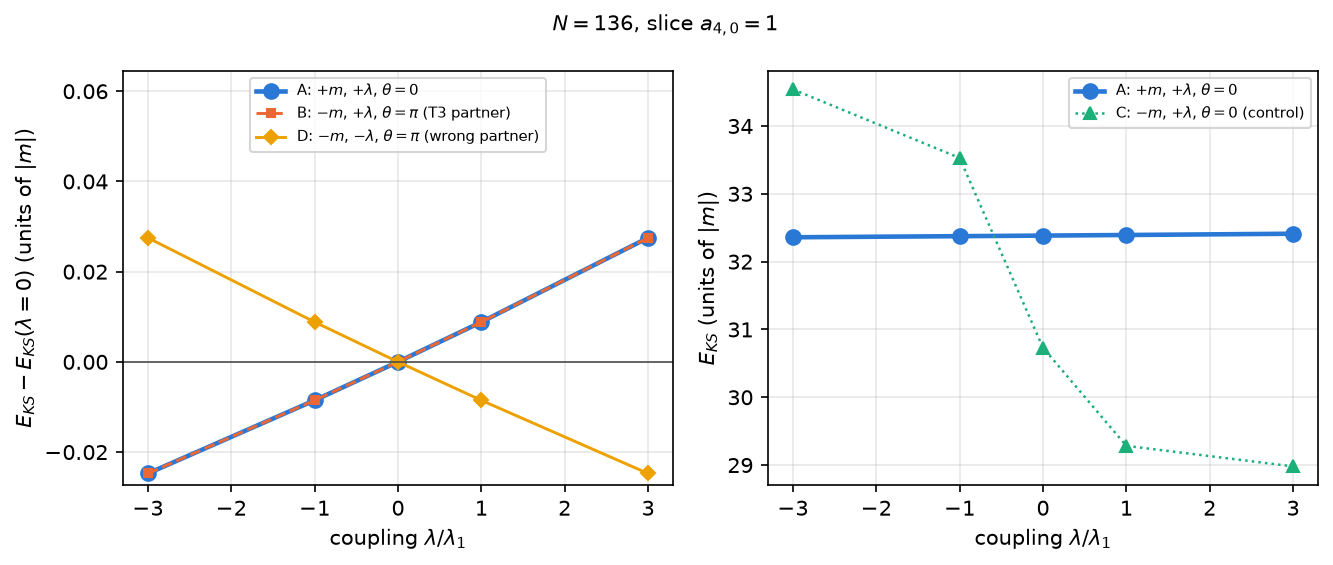

Figure 19a.9 saved as Revision/textbook/figures/19a_9_coupling_scan.png


In [24]:
x = [lam / l1 for tag, lam, margin in COUPLINGS]
E0 = SCAN[("lam0", "A")]["E_KS"]
fig, (left, right) = plt.subplots(1, 2, figsize=(9.0, 3.8))
for kind in "ABD":
    left.plot(x, [SCAN[(tag, kind)]["E_KS"] - E0 for tag, lam, margin in COUPLINGS],
              color=COLOUR[kind], label=NAME[kind], **MARK[kind])
left.set_xlabel("coupling $\\lambda/\\lambda_1$")
left.set_ylabel("$E_{KS} - E_{KS}(\\lambda = 0)$ (units of $|m|$)")
left.axhline(0.0, color="0.3", lw=0.8)
low, high = left.get_ylim()
left.set_ylim(low, high + 0.6 * (high - low))  # room for the legend at the top
left.legend(fontsize=7, loc="upper center")
for kind in "AC":
    right.plot(x, [SCAN[(tag, kind)]["E_KS"] for tag, lam, margin in COUPLINGS],
               color=COLOUR[kind], label=NAME[kind], **MARK[kind])
right.set_xlabel("coupling $\\lambda/\\lambda_1$")
right.set_ylabel("$E_{KS}$ (units of $|m|$)")
right.legend(fontsize=7, loc="upper right")
fig.suptitle("$N = 136$, slice $a_{4,0} = 1$", fontsize=10)
fig.tight_layout()
save_figure(fig, "coupling_scan",
            "Left: the interaction part of the Kohn-Sham energy, $E_{KS}$ minus its "
            "value at $\\lambda = 0$ (units of $|m|$), against the coupling "
            "$\\lambda/\\lambda_1$ for $N = 136$, $a_{4,0} = 1$: universe A (blue), "
            "its T3 partner B with the same coupling (orange, dashed, on top of A) "
            "and D with the reversed coupling (yellow diamonds), which is the "
            "mirror image of A. Right: $E_{KS}$ of A and of the control C (aqua), "
            "which lies $1$ to $3.5$ away from A, above it for negative and below "
            "it for positive couplings. Only $(-m, +\\lambda)$ with the transformed "
            "tip is the partner of $(m, \\lambda)$.")

## 16. Thermal states: equal occupations, chemical potential and free energy

At a temperature $T > 0$ the occupations are the Fermi (Mermin) occupations
$f = 1/(1 + e^{(\varepsilon - \mu)/T})$, with the chemical potential $\mu$ fixed by
the particle number. Since the levels of B are those of A, so are $f$, $\mu$, the
entropy and the free energy $F = E - T S_{ent}$. The next cell solves A, B, C for
$N = 136$, $\lambda_1$, $a_{4,0} = 1$ at the three temperatures of the record
$T = 0.01, 0.02, 0.05$ (margin $0.4$, as the record's thermal states), checks that A
reproduces the record's $\mu$, $E$, entropy and $F$, that B equals A and that the
free energy of C lies $2.5$ to $3.5$ below that of A.

In [25]:
THERMO = read_rows("Revision/kohn_sham/results/thermo/thermodynamics.csv")
TEMPS = [0.01, 0.02, 0.05]
WARM = {}  # (T, kind) -> state
ok_record, ok_partner, ok_control = True, True, True
for T in TEMPS:
    for kind in "ABC":
        WARM[(T, kind)] = universe(kind, l1, 1.0, 136, 0.4, T=T)
    A, B, C = (WARM[(T, kind)] for kind in "ABC")
    F = {kind: WARM[(T, kind)]["E_KS"] - T * WARM[(T, kind)]["entropy"]
         for kind in "ABC"}  # free energy F = E - T S
    row = THERMO[f"N136_lamp1_a10_T{round(1000 * T)}"]
    ok_record &= (close(A["mu_or_fermi_level"], float(row["mu"]))
                  and close(A["E_KS"], float(row["E"]))
                  and close(A["entropy"], float(row["entropy"]))
                  and close(F["A"], float(row["F"])))
    ok_partner &= (close(A["mu_or_fermi_level"], B["mu_or_fermi_level"])
                   and close(A["entropy"], B["entropy"]) and close(F["A"], F["B"])
                   and level_difference(A, B) < TOL)
    ok_control &= 2.5 < F["A"] - F["C"] < 3.5
    mu_A, mu_B, mu_C = (s["mu_or_fermi_level"] for s in (A, B, C))
    F_A, F_B, F_C = (F[kind] for kind in "ABC")
    say(f"T = {T:.2f}: mu A {mu_A:.12f} B {mu_B:.12f} C {mu_C:.6f}; "
        f"F A {F_A:.9f} B {F_B:.9f} C {F_C:.5f}")
check(ok_record, "A reproduces mu, E, entropy and F of the three thermal states",
      record="Revision/kohn_sham/results/thermo/thermodynamics.csv, "
             "N136_lamp1_a10_T10, T20, T50")
check(ok_partner, "B has the occupations, mu, entropy and F of A at every T",
      record="Revision/pairing/kohn_sham/t3-theory.json, statement S4")
check(ok_control, "the control C has a free energy 2.5 to 3.5 below A at every T")

T = 0.01: mu A 0.335053852472 B 0.335053852472 C 0.328004; F A 32.236662364 B
    32.236662364 C 29.08234
T = 0.02: mu A 0.324659275278 B 0.324659275278 C 0.318384; F A 31.588604294 B
    31.588604294 C 28.51026
T = 0.05: mu A 0.295073925379 B 0.295073925379 C 0.289068; F A 27.091045285 B
    27.091045285 C 24.21400
PASS A reproduces mu, E, entropy and F of the three thermal states
     reproduces Revision/kohn_sham/results/thermo/thermodynamics.csv, N136_lamp1_a10_T10,
    T20, T50
PASS B has the occupations, mu, entropy and F of A at every T
     reproduces Revision/pairing/kohn_sham/t3-theory.json, statement S4
PASS the control C has a free energy 2.5 to 3.5 below A at every T


The next cell draws, for $T = 0.05$, the occupation $f$ of every level of A, B and
C against its energy (left; the curve is the Fermi function of A), and the free
energy $F$ against the temperature (right).

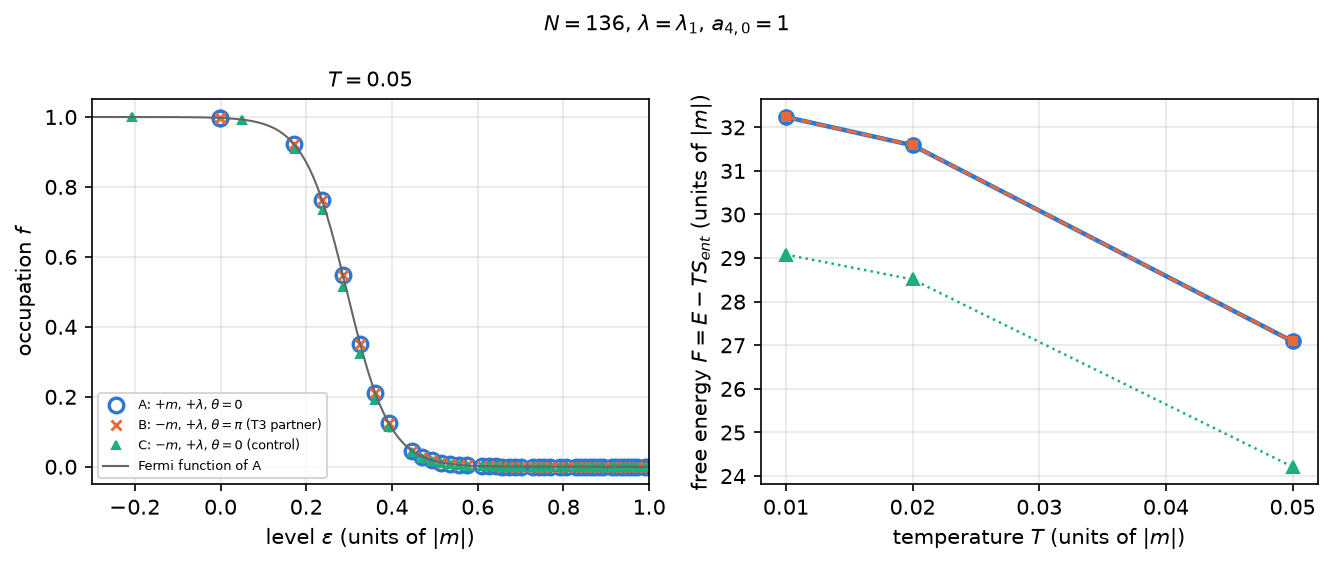

Figure 19a.10 saved as Revision/textbook/figures/19a_10_thermal_states.png


In [26]:
fig, (left, right) = plt.subplots(1, 2, figsize=(9.0, 3.8))
T = 0.05
DOTS = {"A": dict(marker="o", ms=7, ls="none", mfc="none", mew=1.6),
        "B": dict(marker="x", ms=5, ls="none", mew=1.4),
        "C": dict(marker="^", ms=4, ls="none")}
for kind in "ABC":
    lv = WARM[(T, kind)]["levels"]
    left.plot([v[4] for v in lv], [v[6] for v in lv], color=COLOUR[kind],
              label=NAME[kind], **DOTS[kind])
mu = WARM[(T, "A")]["mu_or_fermi_level"]
grid = np.linspace(-0.3, 1.0, 400)
left.plot(grid, 1.0 / (1.0 + np.exp((grid - mu) / T)), color="0.4", lw=1.0,
          label="Fermi function of A")
left.set_xlim(-0.3, 1.0)
left.set_xlabel("level $\\varepsilon$ (units of $|m|$)")
left.set_ylabel("occupation $f$")
left.set_title(f"$T = {T}$", fontsize=10)
left.legend(fontsize=6, loc="lower left")
for kind in "ABC":
    right.plot(TEMPS, [WARM[(t, kind)]["E_KS"] - t * WARM[(t, kind)]["entropy"]
                       for t in TEMPS], color=COLOUR[kind], label=NAME[kind],
               **MARK[kind])
right.set_xlabel("temperature $T$ (units of $|m|$)")
right.set_ylabel("free energy $F = E - TS_{ent}$ (units of $|m|$)")
fig.suptitle("$N = 136$, $\\lambda = \\lambda_1$, $a_{4,0} = 1$", fontsize=10)
fig.tight_layout()
save_figure(fig, "thermal_states",
            "Thermal Kohn-Sham states for $N = 136$, $\\lambda = \\lambda_1$, "
            "$a_{4,0} = 1$. Left: the occupation $f$ of every level against its "
            "energy (units of $|m|$) at $T = 0.05$ for A (blue rings), B (orange "
            "crosses) and C (aqua triangles); the grey curve is the Fermi function "
            "of A. Every cross of B sits in a ring of A. Right: the free energy "
            "$F = E - TS_{ent}$ against the temperature $T$ (units of $|m|$); A and "
            "B coincide, the control C lies $2.5$ to $3.5$ lower.")

## 17. The same runs in the record's demonstration of T3

The Revision record has its own numerical demonstration of T3
(`Revision/pairing/kohn_sham/reports/t3-rust-demo.json`, 7 checks). With the same
solver it solved the members "plus" (our A), "image" (our B) and "control" (our C)
for all 210 states of the canonical matrix, and it stored their numbers in the table
`Revision/pairing/kohn_sham/numerics/results/t3-rust-states.csv`, one row per state.
The runs of this notebook cover 19 of these states: 7 ground states at the slice
$a_{4,0} = 1$ (sections 8, 13 and 15), the other 9 states of the history (section
14) and 3 thermal states (section 16). The next cell reads the report and the table
and prints the record's own largest deviations. Then it checks, state by state: A
equals the record's plus member ($E_{KS}$); B equals its image member ($E_{KS}$,
$\mu$, the entropy and the four EMT integrals); C equals its control ($E_{KS}$); and
D at the coupling $\lambda$ equals the record's image member at $-\lambda$. Last, it
measures in each of the three groups the largest deviation between A and B: the
levels, $E_{KS}$, $\mu$, the entropy, the EMT integrals and the ten profile columns
(even ones equal, odd ones opposite), each relative as in the cells above.

What this agreement tests. The solver follows the angle $\phi$ of the real form,
$(a, b) = r(\cos\phi, \sin\phi)$. The map of T3, $(a, b, j, M) \to (b, a, -j, -M)$,
turns $\phi$ into $\pi/2 - \phi$, and the equation of the angle of B is the equation
of A with $\phi$ replaced by $\pi/2 - \phi$. So the solver does the same arithmetic
for A and B, and their agreement to the last digits is guaranteed by construction:
it tests the transformed boundary conditions, the labels, the filling, the
self-consistency loop and the Mermin root, not the discretisation. The record's
second demonstration (`t3-reference-demo.json`), with the independent
finite-difference reference solver, gives the test that does not depend on the
discretisation.

In [27]:
DEMO = "Revision/pairing/kohn_sham/reports/t3-rust-demo.json"
DEMO_TABLE = "Revision/pairing/kohn_sham/numerics/results/t3-rust-states.csv"
demo = json.loads(repository_file(DEMO).read_text(encoding="utf-8"))
verdict = {c["name"]: c["verdict"] for c in demo["checks"]}
detail = {c["name"]: c["detail"] for c in demo["checks"]}
passed = sum(v == "PASS" for v in verdict.values())
say(f"record: {demo['states']} states, {passed} of {len(verdict)} checks pass")
for name in ("t3_equal_ground_states", "t3_equal_thermal_states"):
    worst = re.search(r"worst deviation (\S+),", detail[name]).group(1)
    say(f"record, {name}: worst deviation {worst}")
DEMO_ROWS = read_rows(DEMO_TABLE)
PAIRS, GROUP = {}, {}  # state id -> [A, B, C]; state id -> group of runs


def add(state_id, group, states):
    """Store the states A, B, C of one state of the record, once."""
    if state_id not in PAIRS:
        PAIRS[state_id], GROUP[state_id] = states, group


for N in (8, 136):
    add(f"N{N}_lamp1_a10", "ground", [SELF[(N, kind)] for kind in "ABC"])
add("N8_lam0_a10", "ground", [FREE8[kind] for kind in "ABC"])
for tag, lam, margin in COUPLINGS:
    add(f"N136_{tag}_a10", "ground", [SCAN[(tag, kind)] for kind in "ABC"])
for N in (136, 688):
    for a4 in SLICES:
        add(f"N{N}_lamp1_a{round(10 * a4):02d}", "history",
            [HIST[(N, kind, a4)] for kind in "ABC"])
for T in TEMPS:
    add(f"N136_lamp1_a10_T{round(1000 * T)}", "thermal",
        [WARM[(T, kind)] for kind in "ABC"])


def relative(a, b):
    """|a - b| relative to max(|a|, 1), the measure of close()."""
    return abs(a - b) / max(abs(a), 1.0)


worst_A, worst_B, worst_C = 0.0, 0.0, 0.0
for state_id, (A, B, C) in PAIRS.items():
    row = DEMO_ROWS[state_id]  # the record's row of this state
    worst_A = max(worst_A, relative(A["E_KS"], float(row["E_KS_plus"])))
    image = [(B["E_KS"], row["E_KS_image"]), (B["mu_or_fermi_level"],
             row["mu_image"]), (B["entropy"], row["entropy_image"])]
    image += [(B["emtIntegrals_2Vol7_int_e6Hy"][c], row[f"int_{c}_image"])
              for c in ("rho", "p3", "p_t", "p8")]
    worst_B = max([worst_B] + [relative(x, float(r)) for x, r in image])
    control = float(row["E_KS_control_untransformed_tip"])
    worst_C = max(worst_C, relative(C["E_KS"], control))
worst_D = max(relative(SCAN[(tag, "D")]["E_KS"],
                       float(DEMO_ROWS[f"N136_{MIRROR[tag]}_a10"]["E_KS_image"]))
              for tag, lam, margin in COUPLINGS)
say(f"{len(PAIRS)} states of the record solved here; largest relative differences "
    f"from the record: A {worst_A:.1e}, B {worst_B:.1e}, C {worst_C:.1e}, "
    f"D {worst_D:.1e}")


def t3_deviation(A, B):
    """Largest deviation of B from A under T3 (levels, E_KS, mu, entropy, EMT
    integrals, profiles with the odd columns reversed)."""
    return max(level_difference(A, B), relative(A["E_KS"], B["E_KS"]),
               relative(A["mu_or_fermi_level"], B["mu_or_fermi_level"]),
               relative(A["entropy"], B["entropy"]), integral_difference(A, B),
               profile_mismatch(A, B))


largest = {}
for group in ("ground", "history", "thermal"):
    ids = [state_id for state_id in PAIRS if GROUP[state_id] == group]
    largest[group] = max(t3_deviation(*PAIRS[state_id][:2]) for state_id in ids)
    say(f"{group}: {len(ids)} pairs A, B; largest T3 deviation "
        f"{largest[group]:.1e}")
check(passed == len(verdict) == 7 and demo["states"] == 210,
      "the record's T3 demonstration passes 7 of 7 checks in 210 states",
      record=DEMO)
check(len(PAIRS) == 19 and worst_A < TOL and worst_B < TOL,
      "A and B equal the record's plus and image members in 19 states",
      record=f"{DEMO}, checks t3_equal_ground_states, t3_equal_thermal_states")
check(worst_C < TOL, "C equals the record's control with the untransformed tip",
      record=f"{DEMO}, check negative_control_untransformed_tip")
check(worst_D < TOL, "D at lambda equals the record's image member at -lambda",
      record=f"{DEMO}, check negative_control_lambda_sign")
check(max(largest.values()) < TOL,
      "B equals A under T3 in all 19 pairs (ground, history, thermal)")

record: 210 states, 7 of 7 checks pass
record, t3_equal_ground_states: worst deviation 2.179e-13
record, t3_equal_thermal_states: worst deviation 3.877e-12
19 states of the record solved here; largest relative differences from the record: A
    4.0e-14, B 2.8e-13, C 7.0e-14, D 0.0e+00
ground: 7 pairs A, B; largest T3 deviation 9.9e-14
history: 9 pairs A, B; largest T3 deviation 1.0e-13
thermal: 3 pairs A, B; largest T3 deviation 8.1e-13
PASS the record's T3 demonstration passes 7 of 7 checks in 210 states
     reproduces Revision/pairing/kohn_sham/reports/t3-rust-demo.json
PASS A and B equal the record's plus and image members in 19 states
     reproduces Revision/pairing/kohn_sham/reports/t3-rust-demo.json, checks
    t3_equal_ground_states, t3_equal_thermal_states
PASS C equals the record's control with the untransformed tip
     reproduces Revision/pairing/kohn_sham/reports/t3-rust-demo.json, check
    negative_control_untransformed_tip
PASS D at lambda equals the record's image mem

## 18. The last check

The last cell checks that the ten figure files exist in the folder
Revision/textbook/figures, prints how many times the solver was run, and prints
the number of checks that passed.

In [28]:
runs = len({id(state) for state in [*SELF.values(), *FREE8.values(), *HIST.values(),
                                    *SCAN.values(), *WARM.values()]})
report("runs of the Rust solver in this notebook", runs)
names = ["level_ladder", "level_differences", "density_profiles",
         "mass_and_potential", "emt_profiles", "zero_modes_n8", "history_energy",
         "history_agreement", "coupling_scan", "thermal_states"]
paths = [output_file(f"{FIGURE_FOLDER}/19a_{k}_{name}.png")
         for k, name in enumerate(names, 1)]
check(runs == 62 and all(path.is_file() for path in paths),
      "every figure file of this notebook exists")
all_checks_passed()

RESULT runs of the Rust solver in this notebook = 62
PASS every figure file of this notebook exists
ALL 37 CHECKS PASSED (notebook 19a)


## 19. What this notebook showed

- PROVED in the records and re-checked here exactly: the author's eight gamma
  matrices are real $16 \times 16$ matrices with entries $-1$, $0$, $+1$ that obey
  $\gamma^a\gamma^b + \gamma^b\gamma^a = 2\eta^{ab}\mathbf{1}$; their product
  $\Gamma = \gamma^{(x_8)}\gamma^{(x_1)}\cdots\gamma^{(x_7)}$ is
  $\mathrm{diag}(-1, \dots, -1, +1, \dots, +1)$ and maps every Kohn-Sham block
  $(j, s_2, s_3)$ onto the block $(-j, s_2, s_3)$ as $s_2\sigma_2$: the map of T3.
- COMPUTED (62 runs of the Rust Kohn-Sham solver, which compare A and B in 19
  states: 7 ground states at $a_{4,0} = 1$, 9 more states of the history and 3
  thermal states; the other runs are the controls C and D): the universe of mass
  $-m$ with the same coupling $+\lambda$ and the transformed tip angle $\pi$ (B) has
  the same Kohn-Sham levels, level by level with the block type and the brane
  parity exchanged, the same occupations, chemical potential, entropy, energy and
  free energy, and the same particle density, potential and energy-momentum
  profiles $\rho$, $p_3$, $p_t$, $p_8$ as the universe of mass $+m$ (A), while its
  scalar density, density $Q$ and effective mass are exactly opposite. The largest
  deviations (section 17) are about $10^{-13}$ for the ground states and the
  history and below $10^{-12}$ for the thermal states: the rounding of the
  computer. This holds for 8, 136 and 688 particles, at every slice of the
  deflating history, for every coupling and at every temperature computed.
- What this agreement tests: the solver's shooting is covariant under the map (the
  angle equation of B is that of A with $\phi \to \pi/2 - \phi$), so the agreement
  to rounding is guaranteed by construction; it tests the solver's handling of the
  transformed boundary conditions, the labels, the filling, the self-consistency
  and the Mermin root. The test that does not depend on the discretisation is the
  record's reference demonstration (`t3-reference-demo.json`).
- COMPUTED: the runs equal the record's own demonstration (`t3-rust-demo.json`,
  table `t3-rust-states.csv`) in the 19 states that both solve: A its plus
  member, B its image member, C its control, D its image at $-\lambda$.
- COMPUTED: the solver's own T3 self-test of the record
  (`ks-rust-solver.json`, check `t3_block_map_solver_selftest`) is reproduced, and
  every A run reproduces the committed canonical state.
- COMPUTED (negative controls): with the untransformed tip (C) the zero modes move
  to the tip, a level appears inside the gap at $\varepsilon_b = m/\cosh(qL)$ with
  $\tanh(qL) = q/m$ (the closed form derived here), and every energy differs; with
  the reversed coupling (D) the energy is that of A at $-\lambda$, not at $\lambda$.
- PROVED elsewhere (records `wolfram-t3.json`, `python-t3.json`, and the
  completion `t3-completion.json`): theorem T3 itself. The runs here demonstrate it
  numerically on the states solved; they are not its proof.
- ASSUMED: the $Z_2$ brane; the tip is a chosen cutoff and T3 needs the transformed
  tip angle; the history is a PRESCRIBED BACKGROUND; mean field without correlation.
- NOT shown: that a universe is created, in pairs or otherwise. T3 maps solutions
  onto solutions; it gives no creation process, rate or amplitude, and it does not
  force the partner to exist.